In [3]:
from pathlib import Path

def find_repo_root(start: Path | None = None, repo_name: str = "Sentinel-FYP") -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if candidate.name == repo_name:
            return candidate
    raise FileNotFoundError(f"Could not find repo root named {repo_name!r} from {start}")

ROOT = find_repo_root()
DATA_DIR = ROOT / "data"


# Road Quality Time-Series Analysis (2020–2023)
This notebook runs 7 analyses on OSM + Sentinel-2 road data:

1. Quarterly trends by class  
2. Inter-annual change (year-over-year)  
3. Stability vs variability by class  
4. Quarterly anomalies  
5. Class divergence over time  
6. Index trend correlation  
7. Road-level time series (small sample)


## Import data

In [4]:
# Imports + plotting setup
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)


In [5]:
# Load data (prefer Parquet, fallback to CSVs)
DATA_DIR = Path(str(DATA_DIR))

# partitioned parquet folder
partitioned_parquet = DATA_DIR / "ghana_parquet"
df = pd.read_parquet(partitioned_parquet)

print("Rows:", len(df))
print("Cols:", len(df.columns))
df.head()


Rows: 18758928
Cols: 9


,osm_id,fclass,quarter,NDVI,NDMI,NDBI,NDWI,BSI,year
0,520162721,trunk,Q1,NaN,NaN,NaN,NaN,NaN,2017
1,574240962,trunk,Q1,0.102122,-0.122559,0.122559,-0.191492,0.158831,2017
2,574240965,trunk,Q1,0.069340,-0.142151,0.142151,-0.160207,0.174891,2017
3,574240966,trunk,Q1,0.069755,-0.136570,0.136570,-0.163025,0.170579,2017
4,574240968,trunk,Q1,0.103850,-0.126520,0.126520,-0.189414,0.158012,2017


In [6]:
# Load the Q3 cloud40 parquet and merge it with the existing Ghana parquet dataset
import pandas as pd
from pathlib import Path

BASE_PARQUET_DIR = Path(str(DATA_DIR / "ghana_parquet"))
Q3_CLOUD40_DIR = Path(str(DATA_DIR / "ghana_q3_cloud40_parquet"))

# load both
df_base = pd.read_parquet(BASE_PARQUET_DIR)
df_q3_40 = pd.read_parquet(Q3_CLOUD40_DIR)

# standardize possible column names
rename_map = {
    "NDVI_mean": "NDVI",
    "NDMI_mean": "NDMI",
    "NDBI_mean": "NDBI",
    "NDWI_mean": "NDWI",
    "BSI_mean": "BSI",
}
df_base = df_base.rename(columns=rename_map)
df_q3_40 = df_q3_40.rename(columns=rename_map)

# keep the common analysis columns
keep_cols = ["osm_id", "fclass", "year", "quarter", "NDVI", "NDMI", "NDBI", "NDWI", "BSI"]
df_base = df_base[keep_cols].copy()
df_q3_40 = df_q3_40[keep_cols].copy()

# remove original Q3 rows for 2020-2023 from the base dataset
replace_years = [2020, 2021, 2022, 2023]
df_base_keep = df_base[
    ~((df_base["year"].isin(replace_years)) & (df_base["quarter"] == "Q3"))
].copy()

# combine base + replacement Q3 cloud40 data
df_all_updated = pd.concat([df_base_keep, df_q3_40], ignore_index=True)

# optional: drop exact duplicates if any
df_all_updated = df_all_updated.drop_duplicates(
    subset=["osm_id", "fclass", "year", "quarter"]
).copy()

print("Base rows:", len(df_base))
print("Replacement Q3 rows:", len(df_q3_40))
print("Final merged rows:", len(df_all_updated))

display(
    df_all_updated.groupby(["year", "quarter"]).size().reset_index(name="rows")
    .sort_values(["year", "quarter"])
)


Base rows: 18758928
Replacement Q3 rows: 1316416
Final merged rows: 8227600


,year,quarter,rows
0,2017,Q1,329104
1,2017,Q4,329104
2,2018,Q1,329104
3,2018,Q2,329104
4,2018,Q4,329104
5,2019,Q1,329104
6,2019,Q2,329104
7,2019,Q3,329104
8,2019,Q4,329104
9,2020,Q1,329104


In [7]:
# Standardize columns + time key + class subset
rename_map = {
    "NDVI_mean": "NDVI",
    "NDMI_mean": "NDMI",
    "NDBI_mean": "NDBI",
    "NDWI_mean": "NDWI",
    "BSI_mean": "BSI",
}
df_all_updated = df_all_updated.rename(columns=rename_map)

required = ["osm_id", "fclass", "year", "quarter", "NDVI", "NDMI", "NDBI", "NDWI", "BSI"]
missing = [c for c in required if c not in df_all_updated.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

keep_classes = ["residential", "service", "unclassified", "trunk", "primary", "secondary", "tertiary"]
df = df_all_updated[df_all_updated ["fclass"].isin(keep_classes)].copy()

quarter_map = {
    "Q1": 1, "Q2": 2, "Q3": 3, "Q4": 4,
    "Jan–Mar": 1, "Apr–Jun": 2, "Jul–Sep": 3, "Oct–Dec": 4,
    "Jan-Mar": 1, "Apr-Jun": 2, "Jul-Sep": 3, "Oct-Dec": 4
}
df["qnum"] = df["quarter"].map(quarter_map)
df = df.dropna(subset=["qnum"]).copy()
df["qnum"] = df["qnum"].astype(int)
df["year"] = df["year"].astype(int)
df["t"] = pd.PeriodIndex.from_fields(year=df["year"], quarter=df["qnum"], freq="Q").to_timestamp()

for c in ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["NDVI", "NDMI", "NDBI", "NDWI", "BSI"],how='all')
print("Rows after cleaning:", len(df))
df.head()




Rows after cleaning: 6375404


,osm_id,fclass,year,quarter,NDVI,NDMI,NDBI,NDWI,BSI,qnum,t
1,574240962,trunk,2017,Q1,0.102122,-0.122559,0.122559,-0.191492,0.158831,1,2017-01-01
2,574240965,trunk,2017,Q1,0.069340,-0.142151,0.142151,-0.160207,0.174891,1,2017-01-01
3,574240966,trunk,2017,Q1,0.069755,-0.136570,0.136570,-0.163025,0.170579,1,2017-01-01
4,574240968,trunk,2017,Q1,0.103850,-0.126520,0.126520,-0.189414,0.158012,1,2017-01-01
5,574240970,trunk,2017,Q1,0.087254,-0.131612,0.131612,-0.171528,0.158645,1,2017-01-01


In [8]:
# Audit unique osm_id retention by quarter (before vs after cleaning)

# --- BEFORE cleaning ---
df_before = pd.read_parquet(partitioned_parquet).copy()

rename_map = {
    "NDVI_mean": "NDVI",
    "NDMI_mean": "NDMI",
    "NDBI_mean": "NDBI",
    "NDWI_mean": "NDWI",
    "BSI_mean": "BSI",
}
df_before = df_before.rename(columns=rename_map)

keep_classes = ["residential", "service", "unclassified", "trunk", "primary", "secondary", "tertiary"]
df_before = df_before[df_before["fclass"].isin(keep_classes)].copy()

quarter_map = {
    "Q1": 1, "Q2": 2, "Q3": 3, "Q4": 4,
    "Jan–Mar": 1, "Apr–Jun": 2, "Jul–Sep": 3, "Oct–Dec": 4,
    "Jan-Mar": 1, "Apr-Jun": 2, "Jul-Sep": 3, "Oct-Dec": 4
}
df_before["qnum"] = df_before["quarter"].map(quarter_map)
df_before = df_before.dropna(subset=["qnum"]).copy()
df_before["qnum"] = df_before["qnum"].astype(int)
df_before["year"] = df_before["year"].astype(int)
df_before["tq"] = df_before["year"].astype(str) + "Q" + df_before["qnum"].astype(str)

# unique osm_id per quarter before ND* numeric/dropna
before_counts = (
    df_before.groupby("tq")["osm_id"]
    .nunique()
    .rename("unique_before")
)

# --- AFTER cleaning ---
# assumes your cleaned dataframe variable is `df`
df_after = df.copy()
df_after["tq"] = df_after["year"].astype(str) + "Q" + df_after["qnum"].astype(str)

after_counts = (
    df_after.groupby("tq")["osm_id"]
    .nunique()
    .rename("unique_after")
)

# compare
audit = pd.concat([before_counts, after_counts], axis=1).fillna(0)
audit["unique_before"] = audit["unique_before"].astype(int)
audit["unique_after"] = audit["unique_after"].astype(int)
audit["removed_unique_osm_id"] = audit["unique_before"] - audit["unique_after"]
audit["removed_pct"] = (audit["removed_unique_osm_id"] / audit["unique_before"] * 100).round(2)

# sort quarter order properly
audit = audit.reset_index()
audit["year"] = audit["tq"].str.extract(r"(\d{4})").astype(int)
audit["q"] = audit["tq"].str.extract(r"Q([1-4])").astype(int)
audit = audit.sort_values(["year", "q"]).drop(columns=["year", "q"]).set_index("tq")

display(audit)
print("Total unique osm_id removed across all quarters (sum of per-quarter removals):", audit["removed_unique_osm_id"].sum())


,unique_before,unique_after,removed_unique_osm_id,removed_pct
tq,,,,
2017Q1,329104,69790,259314,78.79
2017Q4,329104,146876,182228,55.37
2018Q1,329104,196133,132971,40.40
2018Q2,329104,455,328649,99.86
2018Q4,329104,326546,2558,0.78
2019Q1,329104,326546,2558,0.78
2019Q2,329104,281559,47545,14.45
2019Q3,329104,138187,190917,58.01
2019Q4,329104,325749,3355,1.02


Total unique osm_id removed across all quarters (sum of per-quarter removals): 1852196


In [9]:
# Cell 7 — audit NO-DATA (all-NaN) in the new Q3 cloud40 dataset only
# Includes overall quarter summary + class breakdown of NaN rows

import pandas as pd
from pathlib import Path

Q3_CLOUD40_DIR = Path(str(DATA_DIR / "ghana_q3_cloud40_parquet"))

df_q3 = pd.read_parquet(Q3_CLOUD40_DIR).copy()

rename_map = {
    "NDVI_mean": "NDVI",
    "NDMI_mean": "NDMI",
    "NDBI_mean": "NDBI",
    "NDWI_mean": "NDWI",
    "BSI_mean": "BSI",
}
df_q3 = df_q3.rename(columns=rename_map)

keep_classes = ["residential", "service", "unclassified", "trunk", "primary", "secondary", "tertiary"]
df_q3 = df_q3[df_q3["fclass"].isin(keep_classes)].copy()

idx_cols = ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]
for c in idx_cols:
    df_q3[c] = pd.to_numeric(df_q3[c], errors="coerce")

# -----------------------------
# Overall quarter-level summary
# -----------------------------
summary = []
for (year, quarter), g in df_q3.groupby(["year", "quarter"]):
    n = len(g)
    all_nan_mask = g[idx_cols].isna().all(axis=1)
    any_nan_mask = g[idx_cols].isna().any(axis=1)

    summary.append({
        "year": year,
        "quarter": quarter,
        "rows": n,
        "all5_nan_n": int(all_nan_mask.sum()),
        "all5_nan_pct": round(100 * all_nan_mask.mean(), 2),
        "any_nan_n": int(any_nan_mask.sum()),
        "any_nan_pct": round(100 * any_nan_mask.mean(), 2),
        "unique_osm_id": int(g["osm_id"].nunique()),
        "unique_osm_id_all5_nan": int(g.loc[all_nan_mask, "osm_id"].nunique()),
    })

q3_nan_summary = pd.DataFrame(summary).sort_values(["year", "quarter"]).reset_index(drop=True)

# -----------------------------
# Class breakdown of ALL-NaN rows
# -----------------------------
nan_rows = df_q3[df_q3[idx_cols].isna().all(axis=1)].copy()

if len(nan_rows) == 0:
    nan_class_breakdown = pd.DataFrame(columns=[
        "year", "quarter", "fclass", "nan_rows", "pct_of_nan_rows", "pct_of_class_rows"
    ])
else:
    # total NaN rows in each year-quarter
    nan_totals = (
        nan_rows.groupby(["year", "quarter"])
        .size()
        .rename("total_nan_rows")
        .reset_index()
    )

    # NaN rows by class
    nan_by_class = (
        nan_rows.groupby(["year", "quarter", "fclass"])
        .size()
        .rename("nan_rows")
        .reset_index()
    )

    # total rows by class in each year-quarter
    class_totals = (
        df_q3.groupby(["year", "quarter", "fclass"])
        .size()
        .rename("class_rows")
        .reset_index()
    )

    nan_class_breakdown = (
        nan_by_class
        .merge(nan_totals, on=["year", "quarter"], how="left")
        .merge(class_totals, on=["year", "quarter", "fclass"], how="left")
    )

    nan_class_breakdown["pct_of_nan_rows"] = (
        100 * nan_class_breakdown["nan_rows"] / nan_class_breakdown["total_nan_rows"]
    ).round(2)

    nan_class_breakdown["pct_of_class_rows"] = (
        100 * nan_class_breakdown["nan_rows"] / nan_class_breakdown["class_rows"]
    ).round(2)

    nan_class_breakdown = nan_class_breakdown.sort_values(
        ["year", "quarter", "nan_rows"], ascending=[True, True, False]
    ).reset_index(drop=True)

print("Quarter-level NaN summary:")
display(q3_nan_summary)

print("Class breakdown of all-NaN rows:")
display(nan_class_breakdown)


/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_38312/3242407669.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (year, quarter), g in df_q3.groupby(["year", "quarter"]):
/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_38312/3242407669.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  nan_rows.groupby(["year", "quarter"])
/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_38312/3242407669.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observe

Quarter-level NaN summary:


,year,quarter,rows,all5_nan_n,all5_nan_pct,any_nan_n,any_nan_pct,unique_osm_id,unique_osm_id_all5_nan
0,2020,Q3,329104,11729,3.56,11729,3.56,329104,11729
1,2021,Q3,329104,6134,1.86,6134,1.86,329104,6134
2,2022,Q3,329104,165114,50.17,165114,50.17,329104,165114
3,2023,Q3,329104,220696,67.06,220696,67.06,329104,220696


Class breakdown of all-NaN rows:


,year,quarter,fclass,nan_rows,total_nan_rows,class_rows,pct_of_nan_rows,pct_of_class_rows
0,2020,Q3,residential,8768,11729,258612,74.75,3.39
1,2020,Q3,unclassified,1441,11729,23166,12.29,6.22
2,2020,Q3,service,845,11729,36318,7.20,2.33
3,2020,Q3,tertiary,281,11729,4929,2.40,5.70
4,2020,Q3,secondary,177,11729,2516,1.51,7.03
5,2020,Q3,primary,138,11729,1676,1.18,8.23
6,2020,Q3,trunk,79,11729,1887,0.67,4.19
7,2021,Q3,residential,3776,6134,258612,61.56,1.46
8,2021,Q3,service,973,6134,36318,15.86,2.68
9,2021,Q3,unclassified,827,6134,23166,13.48,3.57


# Time Series Analysis

## 1) Quarterly trends by class
Seasonal / long-term shifts in index values by road class.


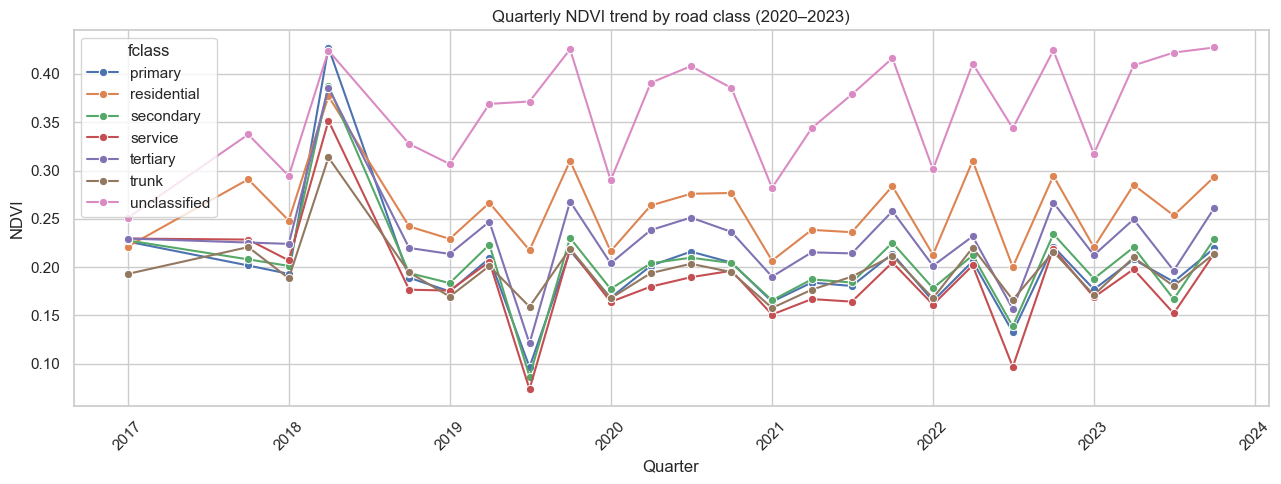

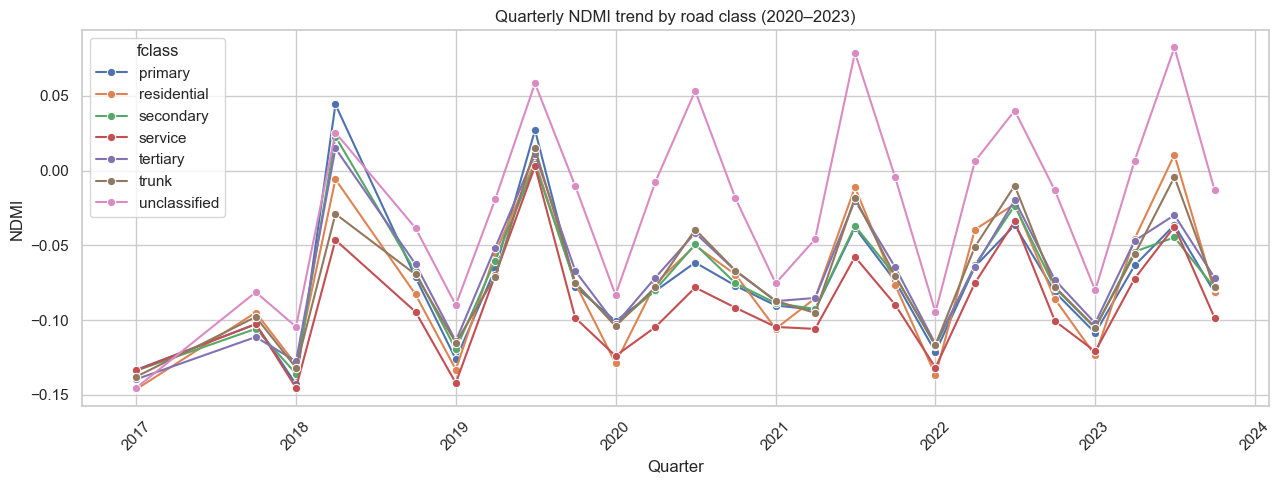

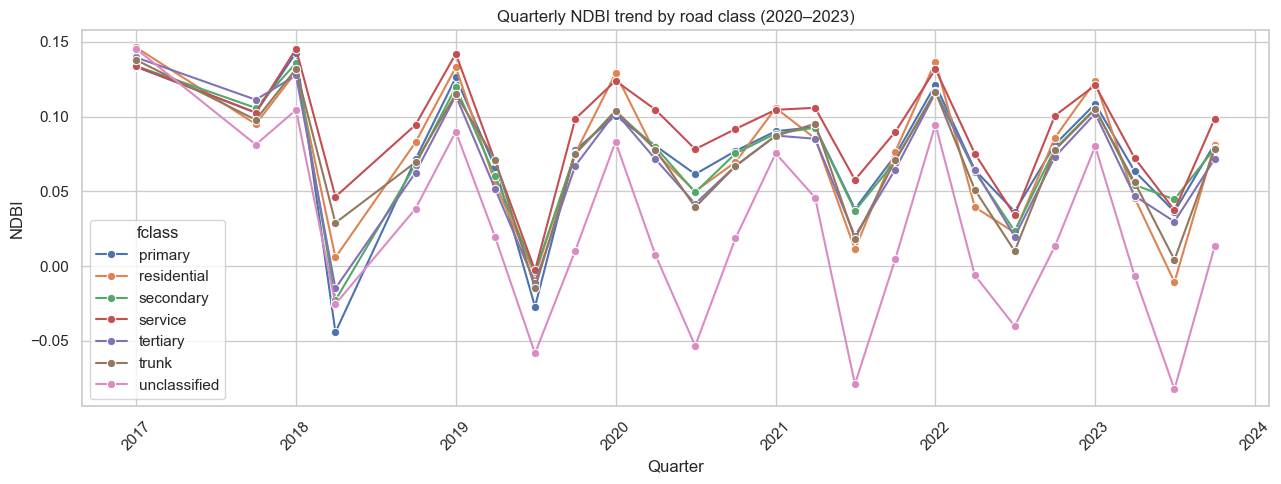

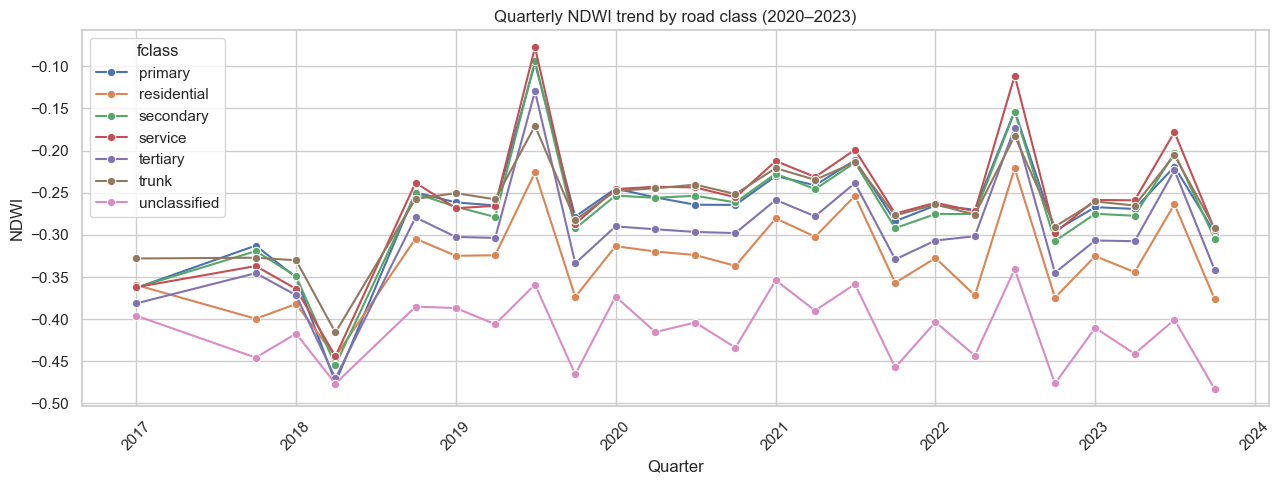

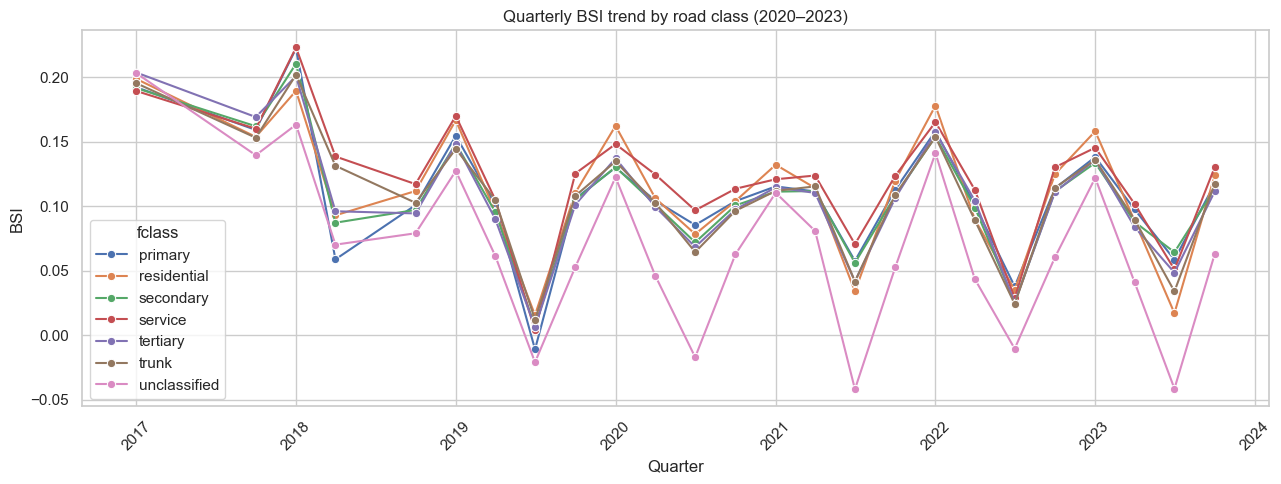

In [10]:
# Quarterly trends by class (time-series)
quarterly = (
    df.groupby(["fclass", "year", "qnum", "t"])[["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]]
    .mean()
    .reset_index()
)

# NDVI trend
plt.figure(figsize=(13, 5))
sns.lineplot(data=quarterly, x="t", y="NDVI", hue="fclass", marker="o")
plt.title("Quarterly NDVI trend by road class (2020–2023)")
plt.xlabel("Quarter")
plt.ylabel("NDVI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# NDMI trend
plt.figure(figsize=(13, 5))
sns.lineplot(data=quarterly, x="t", y="NDMI", hue="fclass", marker="o")
plt.title("Quarterly NDMI trend by road class (2020–2023)")
plt.xlabel("Quarter")
plt.ylabel("NDMI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# NDBI trend
plt.figure(figsize=(13, 5))
sns.lineplot(data=quarterly, x="t", y="NDBI", hue="fclass", marker="o")
plt.title("Quarterly NDBI trend by road class (2020–2023)")
plt.xlabel("Quarter")
plt.ylabel("NDBI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# NDWI trend
plt.figure(figsize=(13, 5))
sns.lineplot(data=quarterly, x="t", y="NDWI", hue="fclass", marker="o")
plt.title("Quarterly NDWI trend by road class (2020–2023)")
plt.xlabel("Quarter")
plt.ylabel("NDWI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# BSI trend
plt.figure(figsize=(13, 5))
sns.lineplot(data=quarterly, x="t", y="BSI", hue="fclass", marker="o")
plt.title("Quarterly BSI trend by road class (2020–2023)")
plt.xlabel("Quarter")
plt.ylabel("BSI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Time-series variation of the five Sentinel-2 indices (2020–2023)

The quarterly time-series plots show that the Sentinel-2 indices vary both **seasonally** and by **road class**, which suggests that the road environment is not static and that surrounding land cover and moisture conditions change over time. This is important because the indices are not measuring the road surface directly, but rather the **spectral context around the road corridor**.

### 1. NDVI
NDVI shows a clear seasonal pattern across all classes, with values generally increasing in wetter/greener periods and decreasing in drier periods.  
- **Unclassified roads** consistently have the highest NDVI, which suggests they are located in greener, less urbanised, or more vegetated environments.  
- **Primary, trunk, and service roads** tend to have lower NDVI, indicating more built-up or disturbed surroundings.  
- This suggests that NDVI is strongly capturing the **urban–rural gradient** around roads.

### 2. NDMI
NDMI varies through time in a way that broadly reflects changing moisture conditions.  
- Most classes remain negative, but their values become less negative in some quarters, indicating relatively wetter surroundings.  
- **Unclassified roads** again tend to show higher NDMI than the major classes, implying that they are more often located in areas with higher moisture retention or less engineered drainage.  
- The quarterly oscillation suggests that moisture availability changes seasonally and that some classes are more exposed to wetness than others.

### 3. NDBI
NDBI tends to be higher for more urban or built-up corridors and lower for less developed surroundings.  
- **Service, residential, primary, and trunk roads** generally show higher NDBI values, which is consistent with roads located in denser built environments.  
- **Unclassified roads** have noticeably lower and sometimes even negative NDBI values, reinforcing the idea that they are found in less built-up and more natural or semi-rural settings.  
- This indicates that NDBI is useful for distinguishing roads embedded in urban infrastructure from roads in less developed areas.

### 4. NDWI
NDWI remains negative across all classes, but the relative differences are still informative.  
- **Unclassified roads** have the most negative NDWI values, which may indicate less open surface water but also a different land-cover background compared with more urban roads.  
- **Service and secondary roads** are often less negative, suggesting comparatively wetter or more water-influenced surroundings in some quarters.  
- The seasonal fluctuations show that wetness conditions near roads vary substantially over time.

### 5. BSI
BSI reflects exposed soil and bare surfaces.  
- Higher BSI values indicate more bare soil or less vegetation cover around the road corridor.  
- Classes associated with more developed or disturbed areas tend to show higher BSI at certain quarters, while greener classes tend to be lower.  
- If unclassified roads have elevated BSI in some periods, this may suggest that they are surrounded by more exposed ground, which is consistent with roads that are less engineered or potentially unpaved.

## Overall interpretation

Taken together, the time-series shows that the indices are capturing a combination of:
- **seasonal vegetation cycles**
- **seasonal moisture changes**
- **built-up intensity**
- **bare soil exposure**
- **differences between major urban roads and more minor/rural roads**

A key result is that **unclassified roads consistently behave differently from the main road classes**:
- they tend to have **higher NDVI**
- often **higher NDMI**
- generally **lower NDBI**
- and distinct NDWI/BSI behaviour

This suggests that unclassified roads are systematically located in different environmental settings than primary, trunk, or service roads. That does not prove road quality directly, but it does show that Sentinel-2 provides useful contextual signals that may be related to road quality, especially when combined with information on pavement, drainage, and road condition.


## 2) Inter-annual change (year-over-year)
How each class changes from year to year.


,fclass,year,NDVI,NDMI,NDBI,NDWI,BSI,NDVI_yoy,NDBI_yoy,NDMI_yoy,BSI_yoy,NDWI_yoy
0,primary,2017,0.209221,-0.112014,0.112014,-0.327922,0.169112,NaN,NaN,NaN,NaN,NaN
1,primary,2018,0.191278,-0.101003,0.101003,-0.292216,0.151363,-0.017943,-0.011011,0.011011,-0.017749,0.035706
2,primary,2019,0.182026,-0.070427,0.070427,-0.238596,0.098237,-0.009252,-0.030576,0.030576,-0.053126,0.053621
3,primary,2020,0.197330,-0.080176,0.080176,-0.257166,0.106039,0.015304,0.009748,-0.009748,0.007802,-0.018571
4,primary,2021,0.185694,-0.073743,0.073743,-0.241690,0.099155,-0.011636,-0.006432,0.006432,-0.006884,0.015477
5,primary,2022,0.184014,-0.079852,0.079852,-0.252356,0.108161,-0.001680,0.006109,-0.006109,0.009006,-0.010666
6,primary,2023,0.198811,-0.078474,0.078474,-0.269679,0.109826,0.014797,-0.001378,0.001378,0.001665,-0.017323
7,residential,2017,0.267527,-0.112202,0.112202,-0.386086,0.168772,NaN,NaN,NaN,NaN,NaN
8,residential,2018,0.244467,-0.100264,0.100264,-0.333291,0.140462,-0.023060,-0.011938,0.011938,-0.028310,0.052795
9,residential,2019,0.262589,-0.078160,0.078160,-0.327897,0.112517,0.018122,-0.022105,0.022105,-0.027945,0.005395


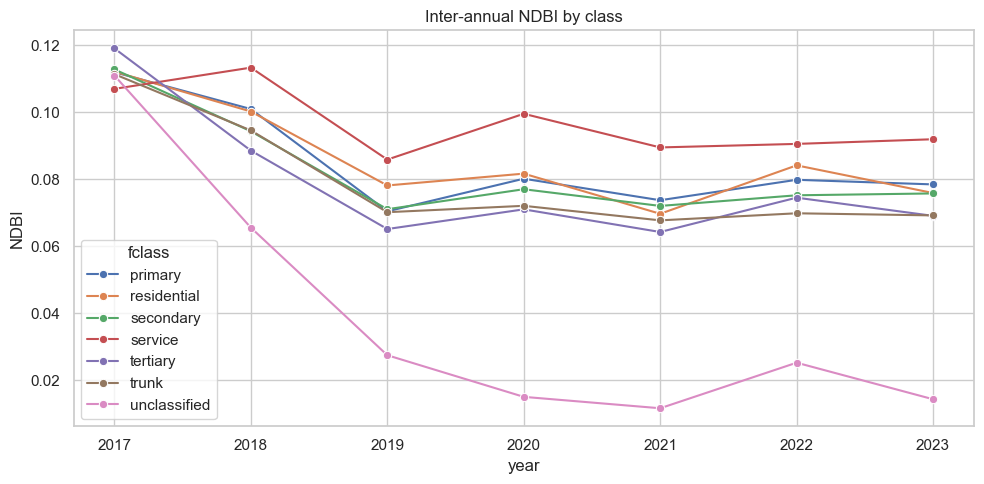

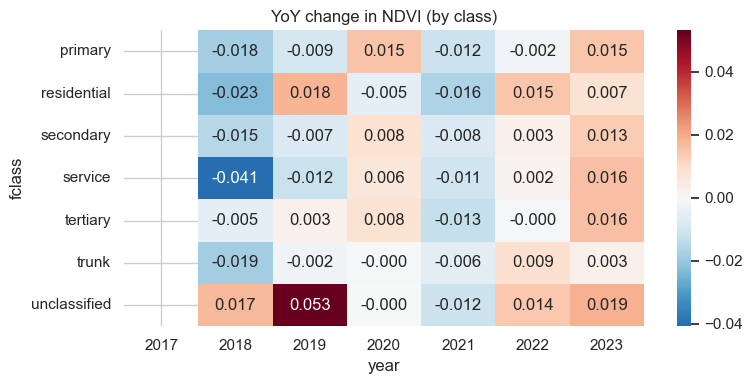

In [11]:
# Yearly means + YoY deltas
yearly = (
    df.groupby(["fclass", "year"])[["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]]
    .mean()
    .reset_index()
    .sort_values(["fclass", "year"])
)

# YoY for NDVI, NDBI (add more if needed)
for idx in ["NDVI", "NDBI", "NDMI", "BSI", "NDWI"]:
    yearly[f"{idx}_yoy"] = yearly.groupby("fclass")[idx].diff()

display(yearly.head(20))

# plot yearly NDBI
plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly, x="year", y="NDBI", hue="fclass", marker="o")
plt.title("Inter-annual NDBI by class")
plt.ylabel("NDBI")
plt.tight_layout()
plt.show()

# heatmap of YoY NDVI
pivot_yoy_ndvi = yearly.pivot(index="fclass", columns="year", values="NDVI_yoy")
plt.figure(figsize=(8, 4))
sns.heatmap(pivot_yoy_ndvi, annot=True, cmap="RdBu_r", center=0, fmt=".3f")
plt.title("YoY change in NDVI (by class)")
plt.tight_layout()
plt.show()


## 3) Stability vs variability by class
Which classes are most stable across quarters?


,NDVI_std,NDMI_std,NDBI_std,NDWI_std,BSI_std
fclass,,,,,
unclassified,0.106056,0.075711,0.075711,0.090116,0.075935
residential,0.076984,0.060329,0.060329,0.081814,0.062901
tertiary,0.065743,0.055677,0.055677,0.075633,0.060721
service,0.064528,0.055440,0.055440,0.081882,0.060982
secondary,0.061777,0.055309,0.055309,0.075054,0.059955
primary,0.058850,0.054797,0.054797,0.069865,0.059577
trunk,0.058540,0.055388,0.055388,0.065903,0.058082


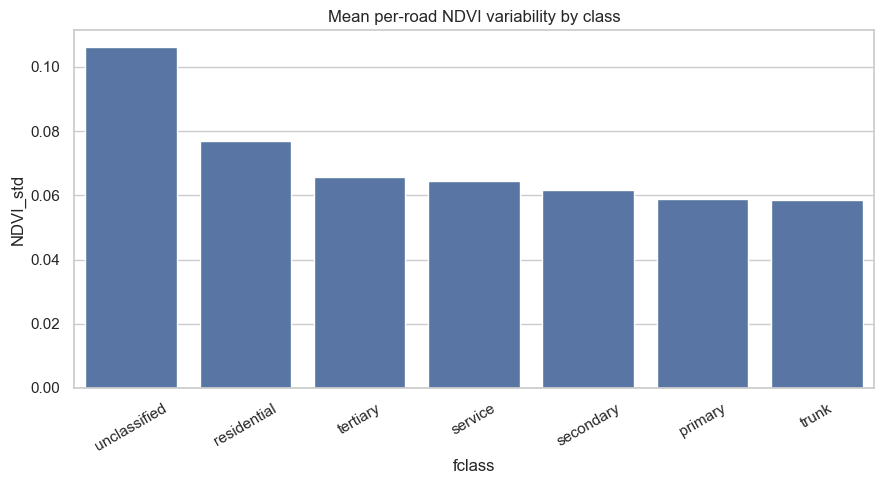

In [12]:
# Cell 6 — Per-road variability across time, summarized by class
road_var = (
    df.groupby(["osm_id", "fclass"])[["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]]
    .std()
    .reset_index()
    .rename(columns={c: f"{c}_std" for c in ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]})
)

stability = (
    road_var.groupby("fclass")[[c for c in road_var.columns if c.endswith("_std")]]
    .mean()
    .sort_values("NDVI_std", ascending=False)
)

display(stability)

plt.figure(figsize=(9, 5))
sns.barplot(data=stability.reset_index(), x="fclass", y="NDVI_std")
plt.title("Mean per-road NDVI variability by class")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 4) Quarterly anomalies
Detect unusual quarter-level spikes/drops by class.


Anomalous class-quarters: 18


,fclass,t,NDVI_z,NDMI_z,NDBI_z,NDWI_z,BSI_z
2,primary,2018-01-01,-0.111768,-1.574720,1.574720,-1.205182,2.337491
3,primary,2018-04-01,4.076905,2.723373,-2.723373,-3.013033,-1.037545
7,primary,2019-07-01,-1.836194,2.328298,-2.328298,2.477803,-2.477237
28,residential,2018-04-01,2.837189,1.476710,-1.476710,-2.170260,-0.378307
44,residential,2022-07-01,-1.410578,1.116133,-1.116133,2.038738,-1.524551
52,secondary,2018-01-01,-0.028817,-1.603964,1.603964,-1.165942,2.267552
53,secondary,2018-04-01,3.656578,2.466543,-2.466543,-2.717969,-0.443868
57,secondary,2019-07-01,-2.292795,1.986429,-1.986429,2.594803,-2.213970
77,service,2018-01-01,0.379677,-1.525890,1.525890,-1.397504,2.158662
78,service,2018-04-01,3.244917,1.217674,-1.217674,-2.463978,0.375176


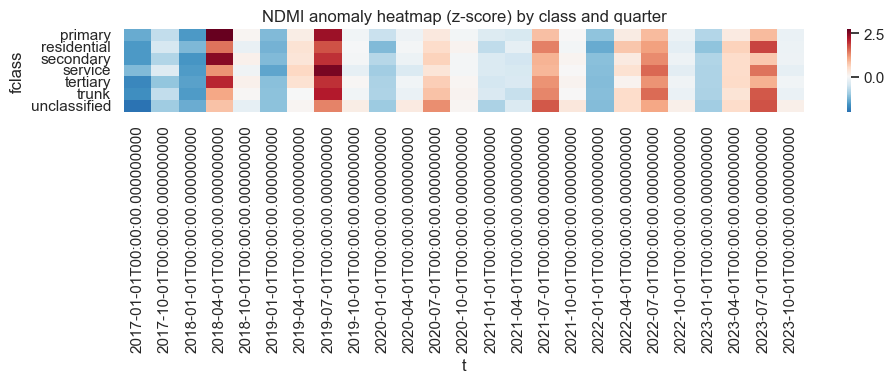

In [13]:
# Anomaly detection with z-scores per class
class_quarter = (
    df.groupby(["fclass", "t"])[["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]]
    .mean()
    .reset_index()
    .sort_values(["fclass", "t"])
)

# z-score within each class time-series
for idx in ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]:
    mu = class_quarter.groupby("fclass")[idx].transform("mean")
    sd = class_quarter.groupby("fclass")[idx].transform("std")
    class_quarter[f"{idx}_z"] = (class_quarter[idx] - mu) / sd

# flag anomalies where |z| >= 2
anom_cols = [f"{i}_z" for i in ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]]
class_quarter["is_anomaly"] = class_quarter[anom_cols].abs().max(axis=1) >= 2

anomalies = class_quarter[class_quarter["is_anomaly"]].copy()
print("Anomalous class-quarters:", len(anomalies))
display(anomalies[["fclass", "t"] + anom_cols].sort_values(["fclass", "t"]))

# heatmap example for NDMI z-score
hm = class_quarter.pivot(index="fclass", columns="t", values="NDMI_z")
plt.figure(figsize=(10, 4))
sns.heatmap(hm, cmap="RdBu_r", center=0, annot=False)
plt.title("NDMI anomaly heatmap (z-score) by class and quarter")
plt.tight_layout()
plt.show()


## 5) Class divergence over time
Do classes become more similar or more different over time?


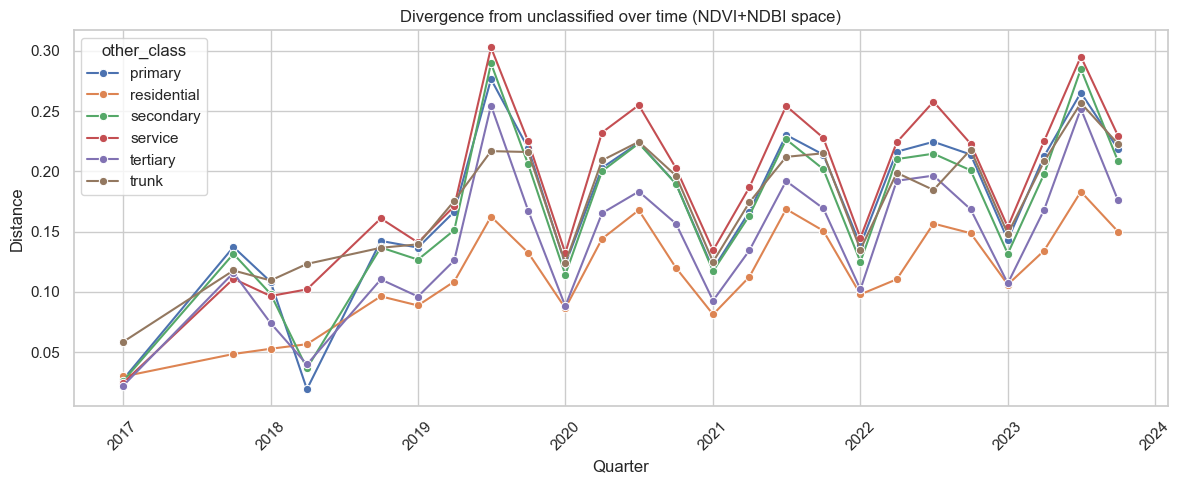

In [14]:
# Divergence using Euclidean distance between class centroids
# centroid features per class-quarter
centroids = (
    df.groupby(["fclass", "t"])[["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]]
    .mean()
    .reset_index()
)

def pairwise_dist_for_time(sub):
    rows = []
    classes = sub["fclass"].tolist()
    vals = sub.set_index("fclass")[["NDVI", "NDBI"]]
    for a, b in combinations(classes, 2):
        d = np.linalg.norm(vals.loc[a].values - vals.loc[b].values)
        rows.append({"class_a": a, "class_b": b, "dist_ndvi_ndbi": d})
    out = pd.DataFrame(rows)
    return out

dist_parts = []
for t, sub in centroids.groupby("t"):
    d = pairwise_dist_for_time(sub)
    d["t"] = t
    dist_parts.append(d)

dist_df = pd.concat(dist_parts, ignore_index=True)

# Focus: unclassified vs each other class
u_dist = dist_df[(dist_df["class_a"] == "unclassified") | (dist_df["class_b"] == "unclassified")].copy()
u_dist["other_class"] = np.where(u_dist["class_a"] == "unclassified", u_dist["class_b"], u_dist["class_a"])

plt.figure(figsize=(12, 5))
sns.lineplot(data=u_dist, x="t", y="dist_ndvi_ndbi", hue="other_class", marker="o")
plt.title("Divergence from unclassified over time (NDVI+NDBI space)")
plt.xlabel("Quarter")
plt.ylabel("Distance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6) Index trend correlation
Do index trends move together over time?


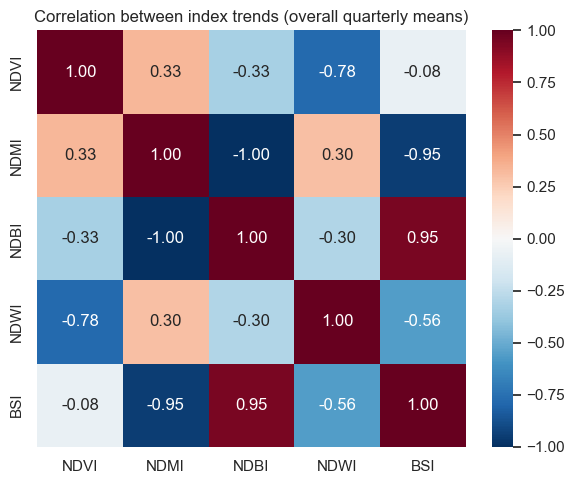

Example correlation matrix for class = primary


,NDVI,NDMI,NDBI,NDWI,BSI
NDVI,1.000000,0.290849,-0.290849,-0.873394,0.066218
NDMI,0.290849,1.000000,-1.000000,0.163865,-0.902587
NDBI,-0.290849,-1.000000,1.000000,-0.163865,0.902587
NDWI,-0.873394,0.163865,-0.163865,1.000000,-0.532178
BSI,0.066218,-0.902587,0.902587,-0.532178,1.000000


In [15]:
# Correlation of index trends over time
overall_q = (
    df.groupby("t")[["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]]
    .mean()
    .sort_index()
)

corr_idx = overall_q.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr_idx, annot=True, cmap="RdBu_r", center=0, fmt=".2f")
plt.title("Correlation between index trends (overall quarterly means)")
plt.tight_layout()
plt.show()

# optional by class
corr_by_class = {}
for cls, sub in df.groupby("fclass"):
    ts = sub.groupby("t")[["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]].mean()
    corr_by_class[cls] = ts.corr()

# print one example
print("Example correlation matrix for class = primary")
display(corr_by_class.get("primary"))


## 7) Road-level time series (small sample)
Track individual roads across quarters (representative sample).


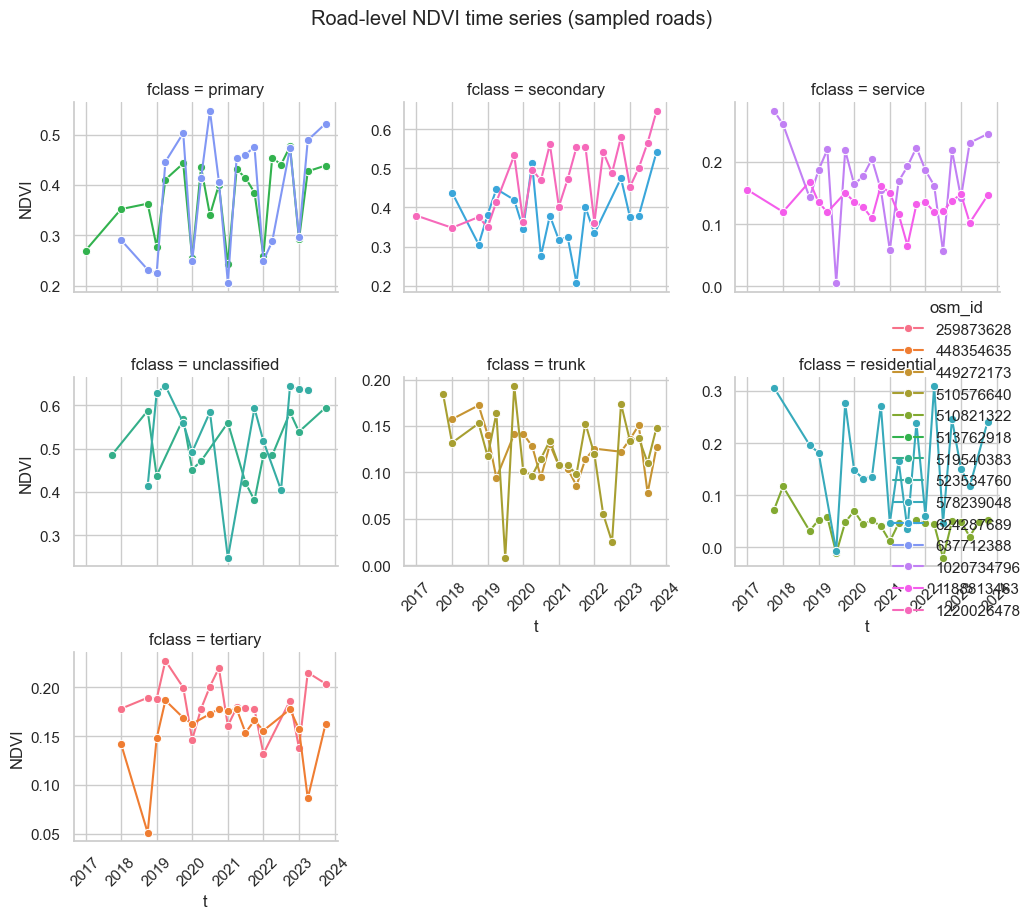

In [16]:
#  Sample representative roads and plot time series
# Keep roads with enough quarterly observations
road_counts = df.groupby("osm_id")["t"].nunique()
eligible_ids = road_counts[road_counts >= 8].index  # at least half of 16 quarters
df_eligible = df[df["osm_id"].isin(eligible_ids)].copy()

# sample 2 roads per class (adjust n if needed)
sample_rows = []
rng = np.random.default_rng(42)

for cls, sub in df_eligible.groupby("fclass"):
    ids = sub["osm_id"].drop_duplicates().values
    if len(ids) == 0:
        continue
    n = min(2, len(ids))
    chosen = rng.choice(ids, size=n, replace=False)
    sample_rows.append(pd.DataFrame({"fclass": cls, "osm_id": chosen}))

sample_ids = pd.concat(sample_rows, ignore_index=True)
df_sample = df_eligible.merge(sample_ids, on=["fclass", "osm_id"], how="inner")

# plot NDVI per sampled road
g = sns.FacetGrid(
    df_sample.sort_values("t"),
    col="fclass",
    hue="osm_id",
    col_wrap=3,
    sharey=False,
    height=3
)
g.map_dataframe(sns.lineplot, x="t", y="NDVI", marker="o")
g.add_legend()
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)
g.fig.suptitle("Road-level NDVI time series (sampled roads)", y=1.02)
plt.tight_layout()
plt.show()


## Conclusion

1) Quarterly NDVI trend by class

What it shows: clear seasonal cycle across all classes (mid-year peaks, early-year dips), with unclassified consistently higher NDVI context.

ML impact:
- Add time features: quarter_sin, quarter_cos, or quarter one-hot.
- Add per-road seasonal amplitude: NDVI_max - NDVI_min.
- Add class-relative features: road NDVI minus class-quarter mean.

2) Inter-annual NDBI + YoY NDVI heatmap

What it shows: 2022 is a shift year (NDVI jumps for all classes; NDBI peaks in many classes). 2023 partially normalizes.

ML impact:
- Add year and a post_2021 / year_index feature.
- Add YoY deltas per road: d_NDVI, d_NDBI, d_NDMI.
- Use time-based validation only (train older years, test newer years), not random split.

3) Stability/variability table

What it shows: unclassified has highest temporal variability across indices; primary is most stable.

ML impact:
- Keep variability features as core predictors:
- NDVI_std, NDMI_std, NDBI_std, NDWI_std, BSI_std
- Add robust spread too: IQR or MAD (less sensitive to outliers).

4) Quarterly anomalies table + heatmap

What it shows: synchronized anomalies around 2022-07 and 2023-07 (higher NDVI/NDMI, lower NDBI/BSI), likely seasonal/rainfall-driven regime shifts.

ML impact:
- Add anomaly-count features per road:
- num_wet_anomalies, num_dry_anomalies
- Add persistence features: % quarters NDMI_z > 1, % quarters NDWI_z > 1
- Consider excluding extreme anomaly quarters in sensitivity runs.

5) Divergence from unclassified over time

What it shows: distance between unclassified and other classes changes by quarter; divergence is dynamic, not fixed.

ML impact:
- Add dynamic distance features per quarter: distance to class centroids in (NDVI, NDBI) or full index space.
- For weak-labeling/reclassification, use rolling average distance, not single-quarter distance.

6) Index trend correlation matrix

What it shows: very high multicollinearity (NDMI vs NDBI about -1, NDBI vs BSI very high).
ML impact:
- Do not feed all raw indices blindly.
Use either:
- feature subset (e.g., NDVI, NDWI, BSI) or PCA or regularized models.
- Tree models can handle correlation better, but interpretation becomes unstable if all collinear features remain.

7) Road-level sample plots

What it shows: high heterogeneity within the same class (some roads flat, some volatile).
ML impact:
- Aggregate per-road temporal features (mean/std/slope/amplitude/persistence) rather than using only class averages.
- Consider road-level grouping in validation (GroupKFold by osm_id if using quarter-level rows).


**Recommended feature block for your first model**
Use these as your baseline predictors:

- Means: NDVI_mean, NDMI_mean, NDBI_mean, NDWI_mean, BSI_mean
- Variability: std for each index
- Trend: slope for each index across quarters
- Seasonality: amplitude for each index
- Persistence: wet/dry anomaly proportions
- Time: year_index, quarter_sin, quarter_cos


# Further analysis


In [17]:
# Region lookup merge (fix dtype mismatch)
lookup = pd.read_csv(str(DATA_DIR / "roads_region_lookup.csv"))

df["osm_id"] = df["osm_id"].astype(str).str.strip()
lookup["osm_id"] = lookup["osm_id"].astype(str).str.strip()

# optional: remove '.0' artifacts if any
df["osm_id"] = df["osm_id"].str.replace(r"\.0$", "", regex=True)
lookup["osm_id"] = lookup["osm_id"].str.replace(r"\.0$", "", regex=True)

df_reg = df.merge(lookup.drop_duplicates("osm_id"), on="osm_id", how="left")
df_reg["region"].value_counts(dropna=False)



region
Greater Accra    1964854
Ashanti          1160798
Eastern           548841
Central           483633
Northern          379351
Volta             304508
Western           270048
Bono              261600
Upper West        206340
Bono East         205235
Upper East        182323
Savannah          113313
Ahafo             102735
Western North      72733
Oti                46640
NaN                36724
Northern East      35728
Name: count, dtype: int64

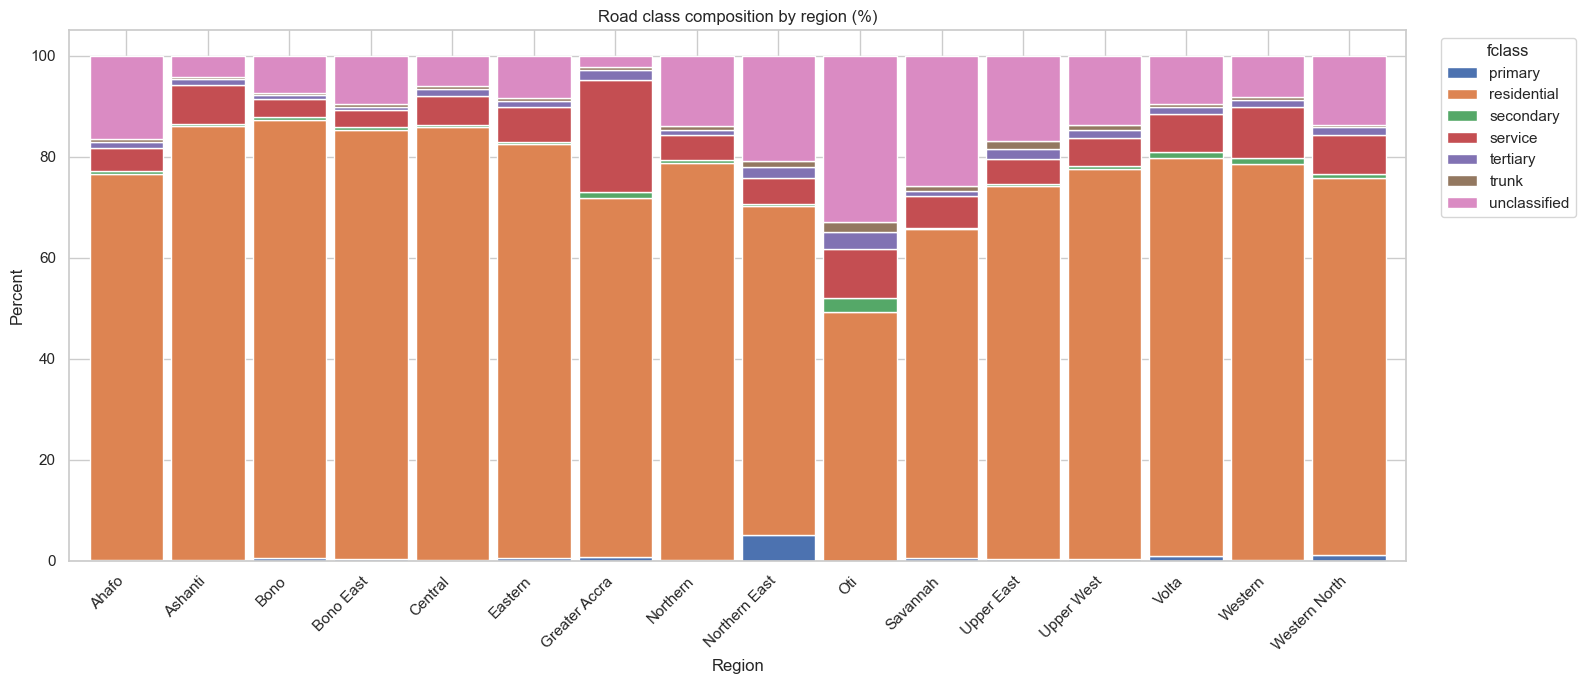

In [18]:
# count roads per region x fclass
region_fclass_counts = (
    df_reg.groupby(["region", "fclass"])
    .size()
    .reset_index(name="count")
    .sort_values(["region", "count"], ascending=[True, False])
)

# 2) stacked bar chart: percent composition per region
pivot = pd.pivot_table(
    df_reg,
    index="region",
    columns="fclass",
    values="osm_id",
    aggfunc="count",
    fill_value=0
)

pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

ax = pct.sort_index().plot(kind="bar", stacked=True, figsize=(16, 7), width=0.9)
ax.set_title("Road class composition by region (%)")
ax.set_xlabel("Region")
ax.set_ylabel("Percent")
plt.xticks(rotation=45, ha="right")
plt.legend(title="fclass", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


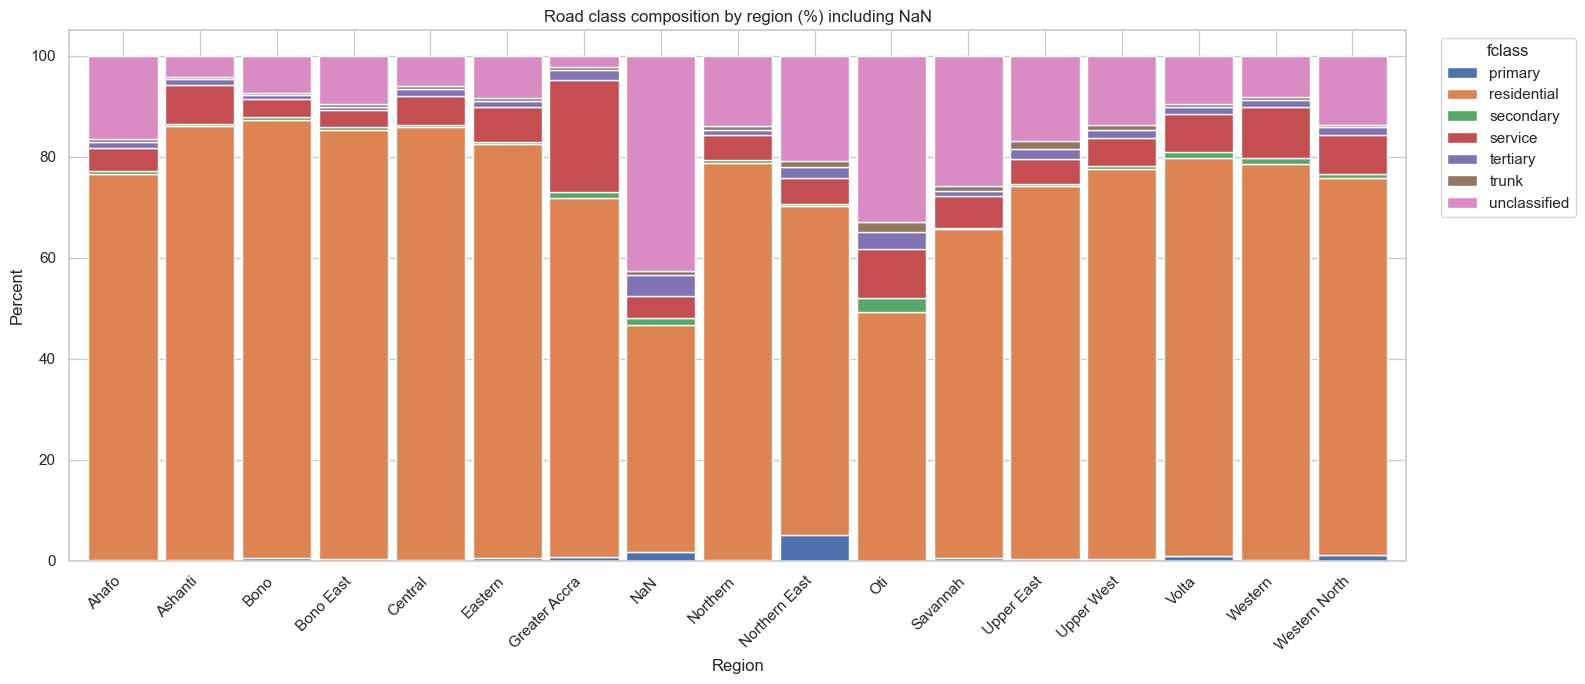

In [19]:
# keep NaN as explicit category
df_plot = df_reg.copy()
df_plot["region_plot"] = df_plot["region"].fillna("NaN")

# grouped bars (counts)
counts = (
    df_plot.groupby(["region_plot", "fclass"])
    .size()
    .reset_index(name="count")
)

# stacked percent bars (including NaN)
pivot = pd.pivot_table(
    df_plot,
    index="region_plot",
    columns="fclass",
    values="osm_id",
    aggfunc="count",
    fill_value=0
)

pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

ax = pct.sort_index().plot(kind="bar", stacked=True, figsize=(16, 7), width=0.9)
ax.set_title("Road class composition by region (%) including NaN")
ax.set_xlabel("Region")
ax.set_ylabel("Percent")
plt.xticks(rotation=45, ha="right")
plt.legend(title="fclass", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [20]:
# 1) type check
print(df["osm_id"].dtype, lookup["osm_id"].dtype)

# 2) normalize ids as strings
df["osm_id"] = df["osm_id"].astype(str).str.strip()
lookup["osm_id"] = lookup["osm_id"].astype(str).str.strip()

# 3) unmatched IDs
unmatched = set(df["osm_id"]) - set(lookup["osm_id"])
print("Unmatched count:", len(unmatched))

# 4) after merge, inspect NaN rows
df_reg = df.merge(lookup.drop_duplicates("osm_id"), on="osm_id", how="left")
print("NaN region rows:", df_reg["region"].isna().sum())
df_reg[df_reg["region"].isna()].head()


object object
Unmatched count: 1714
NaN region rows: 36724


,osm_id,fclass,year,quarter,NDVI,NDMI,NDBI,NDWI,BSI,qnum,t,system:index,region,.geo
223,1455401537,unclassified,2017,Q1,0.151249,-0.210557,0.210557,-0.318766,0.244600,1,2017-01-01,NaN,NaN,NaN
451,763115762,trunk,2017,Q1,0.099610,-0.179260,0.179260,-0.244116,0.227998,1,2017-01-01,NaN,NaN,NaN
490,276209115,trunk,2017,Q1,0.129184,-0.234511,0.234511,-0.319842,0.288110,1,2017-01-01,NaN,NaN,NaN
491,276210072,trunk,2017,Q1,0.127092,-0.235749,0.235749,-0.321434,0.288941,1,2017-01-01,NaN,NaN,NaN
494,313523494,trunk,2017,Q1,0.136365,-0.169808,0.169808,-0.257065,0.207777,1,2017-01-01,NaN,NaN,NaN


In [21]:
# Cell 1 — prep
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dfx = df_reg.copy()
dfx["region"] = dfx["region"].fillna("Unknown")

# ensure expected columns exist
needed = ["region", "fclass", "year", "quarter", "NDVI", "NDMI", "NDBI", "NDWI", "BSI"]
missing = [c for c in needed if c not in dfx.columns]
print("Missing columns:", missing)

# quarter ordering
q_map = {"Q1":1, "Q2":2, "Q3":3, "Q4":4}
if "qnum" not in dfx.columns:
    dfx["qnum"] = dfx["quarter"].map(q_map)

dfx["t"] = pd.PeriodIndex(year=dfx["year"].astype(int), quarter=dfx["qnum"].astype(int), freq="Q").to_timestamp()


Missing columns: []


/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_38312/665851440.py:19: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  dfx["t"] = pd.PeriodIndex(year=dfx["year"].astype(int), quarter=dfx["qnum"].astype(int), freq="Q").to_timestamp()


In [22]:
# counts and composition (%)
counts = (
    dfx.groupby(["region","fclass"])
    .size()
    .reset_index(name="count")
)

pivot_counts = counts.pivot(index="region", columns="fclass", values="count").fillna(0)
pivot_pct = pivot_counts.div(pivot_counts.sum(axis=1), axis=0) * 100

display(pivot_counts)
display(pivot_pct.round(2))

fclass,primary,residential,secondary,service,tertiary,trunk,unclassified
region,,,,,,,
Ahafo,243.0,78533.0,570.0,4578.0,1161.0,607.0,17043.0
Ashanti,1710.0,997255.0,5478.0,88343.0,15212.0,3494.0,49306.0
Bono,1452.0,226959.0,1529.0,9170.0,2230.0,871.0,19389.0
Bono East,671.0,174354.0,1322.0,6756.0,1187.0,1195.0,19750.0
Central,1112.0,414587.0,1577.0,27903.0,7018.0,2397.0,29039.0
Eastern,2955.0,449659.0,2860.0,38045.0,5988.0,3576.0,45758.0
Greater Accra,15316.0,1397387.0,22162.0,435645.0,37671.0,11982.0,44691.0
Northern,787.0,297855.0,2244.0,18967.0,4052.0,2468.0,52978.0
Northern East,1847.0,23258.0,118.0,1846.0,812.0,382.0,7465.0


fclass,primary,residential,secondary,service,tertiary,trunk,unclassified
region,,,,,,,
Ahafo,0.24,76.44,0.55,4.46,1.13,0.59,16.59
Ashanti,0.15,85.91,0.47,7.61,1.31,0.30,4.25
Bono,0.56,86.76,0.58,3.51,0.85,0.33,7.41
Bono East,0.33,84.95,0.64,3.29,0.58,0.58,9.62
Central,0.23,85.72,0.33,5.77,1.45,0.50,6.00
Eastern,0.54,81.93,0.52,6.93,1.09,0.65,8.34
Greater Accra,0.78,71.12,1.13,22.17,1.92,0.61,2.27
Northern,0.21,78.52,0.59,5.00,1.07,0.65,13.97
Northern East,5.17,65.10,0.33,5.17,2.27,1.07,20.89


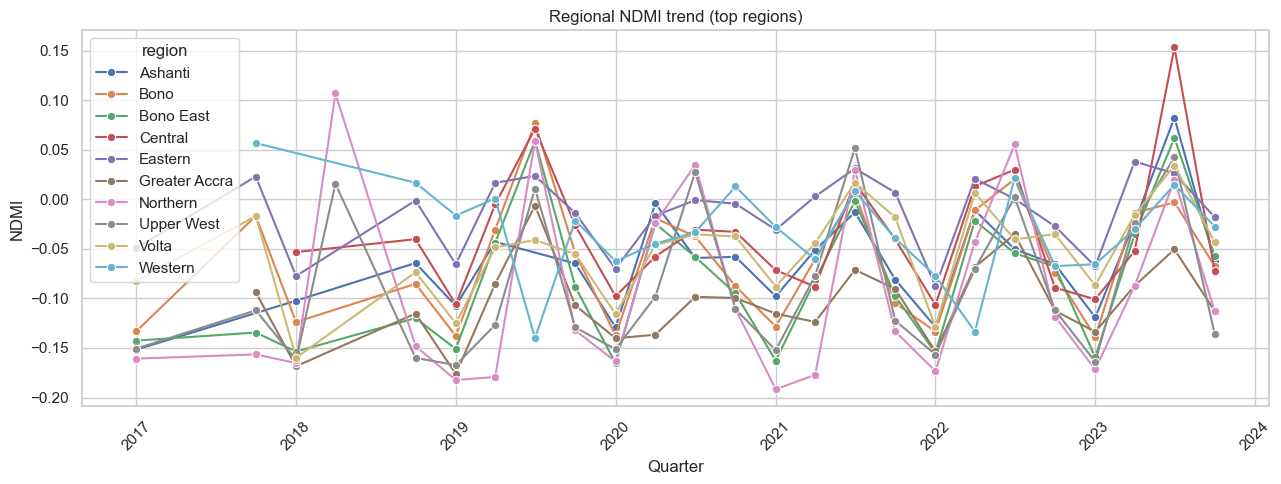

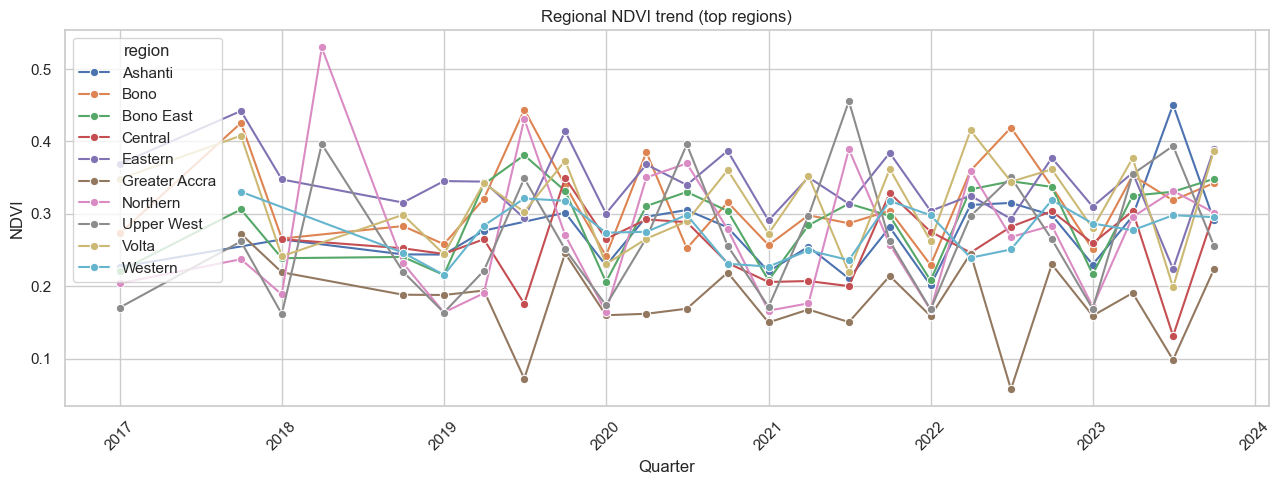

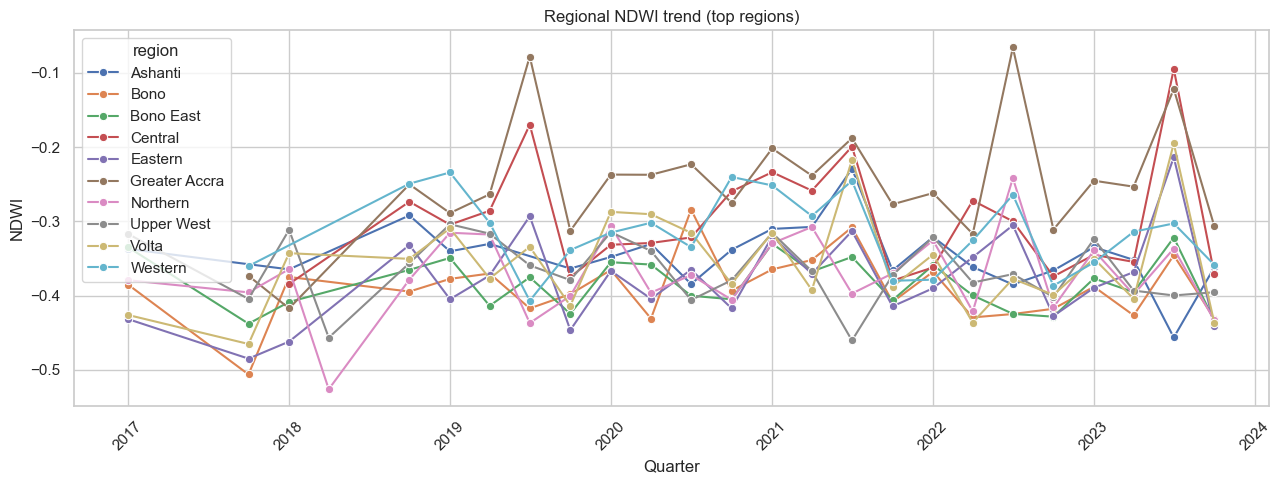

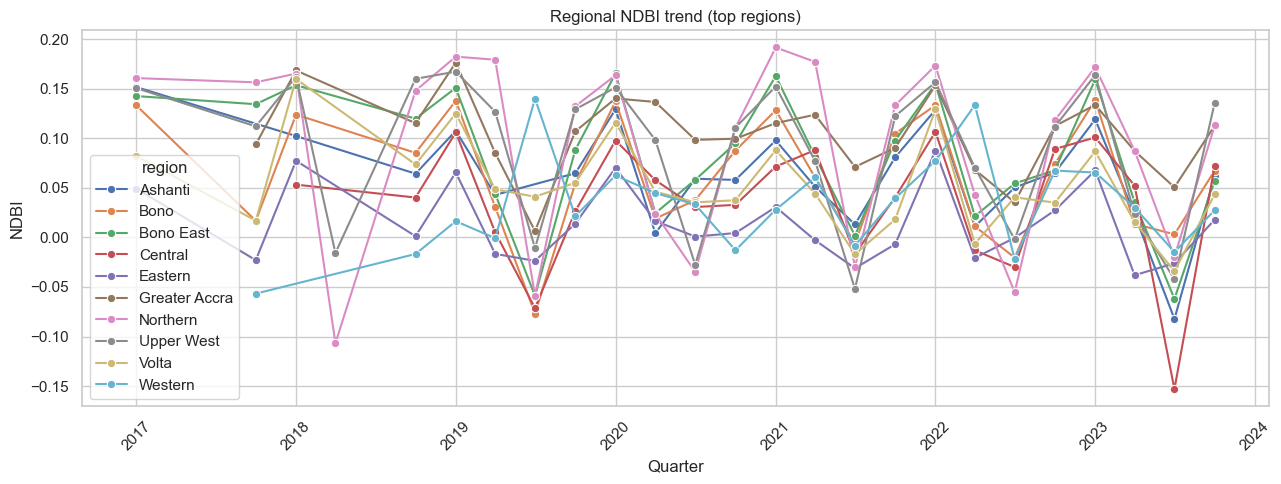

In [23]:
# Overall regional quarterly trends
reg_q = (
    dfx.groupby(["region", "t"])[["NDVI","NDMI","NDBI","NDWI","BSI"]]
    .mean()
    .reset_index()
)

# choose top regions by row count for readability
top_regions = dfx["region"].value_counts().head(10).index.tolist()
plot_df = reg_q[reg_q["region"].isin(top_regions)]

plt.figure(figsize=(13,5))
sns.lineplot(data=plot_df, x="t", y="NDMI", hue="region", marker="o")
plt.title("Regional NDMI trend (top regions)")
plt.xlabel("Quarter")
plt.ylabel("NDMI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(13,5))
sns.lineplot(data=plot_df, x="t", y="NDVI", hue="region", marker="o")
plt.title("Regional NDVI trend (top regions)")
plt.xlabel("Quarter")
plt.ylabel("NDVI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(13,5))
sns.lineplot(data=plot_df, x="t", y="NDWI", hue="region", marker="o")
plt.title("Regional NDWI trend (top regions)")
plt.xlabel("Quarter")
plt.ylabel("NDWI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(13,5))
sns.lineplot(data=plot_df, x="t", y="NDBI", hue="region", marker="o")
plt.title("Regional NDBI trend (top regions)")
plt.xlabel("Quarter")
plt.ylabel("NDBI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


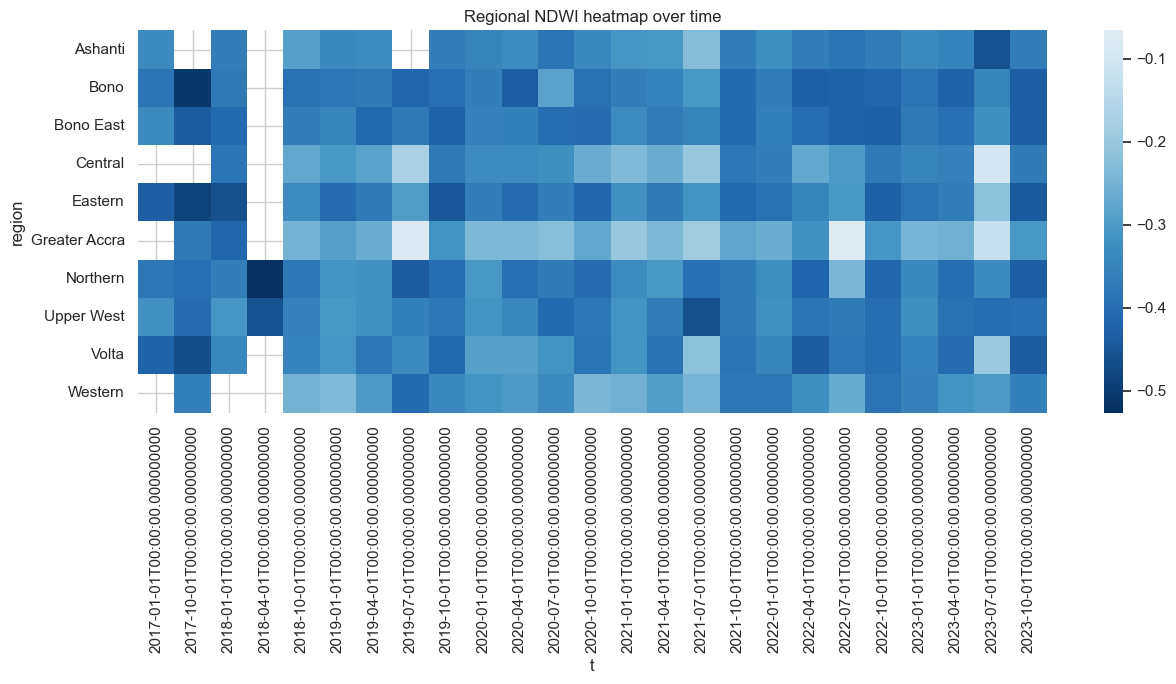

In [24]:
# Regional heatmap (quarterly NDWI)
hm = (
    reg_q[reg_q["region"].isin(top_regions)]
    .pivot(index="region", columns="t", values="NDWI")
)

plt.figure(figsize=(13,7))
sns.heatmap(hm, cmap="RdBu_r", center=0)
plt.title("Regional NDWI heatmap over time")
plt.tight_layout()
plt.show()


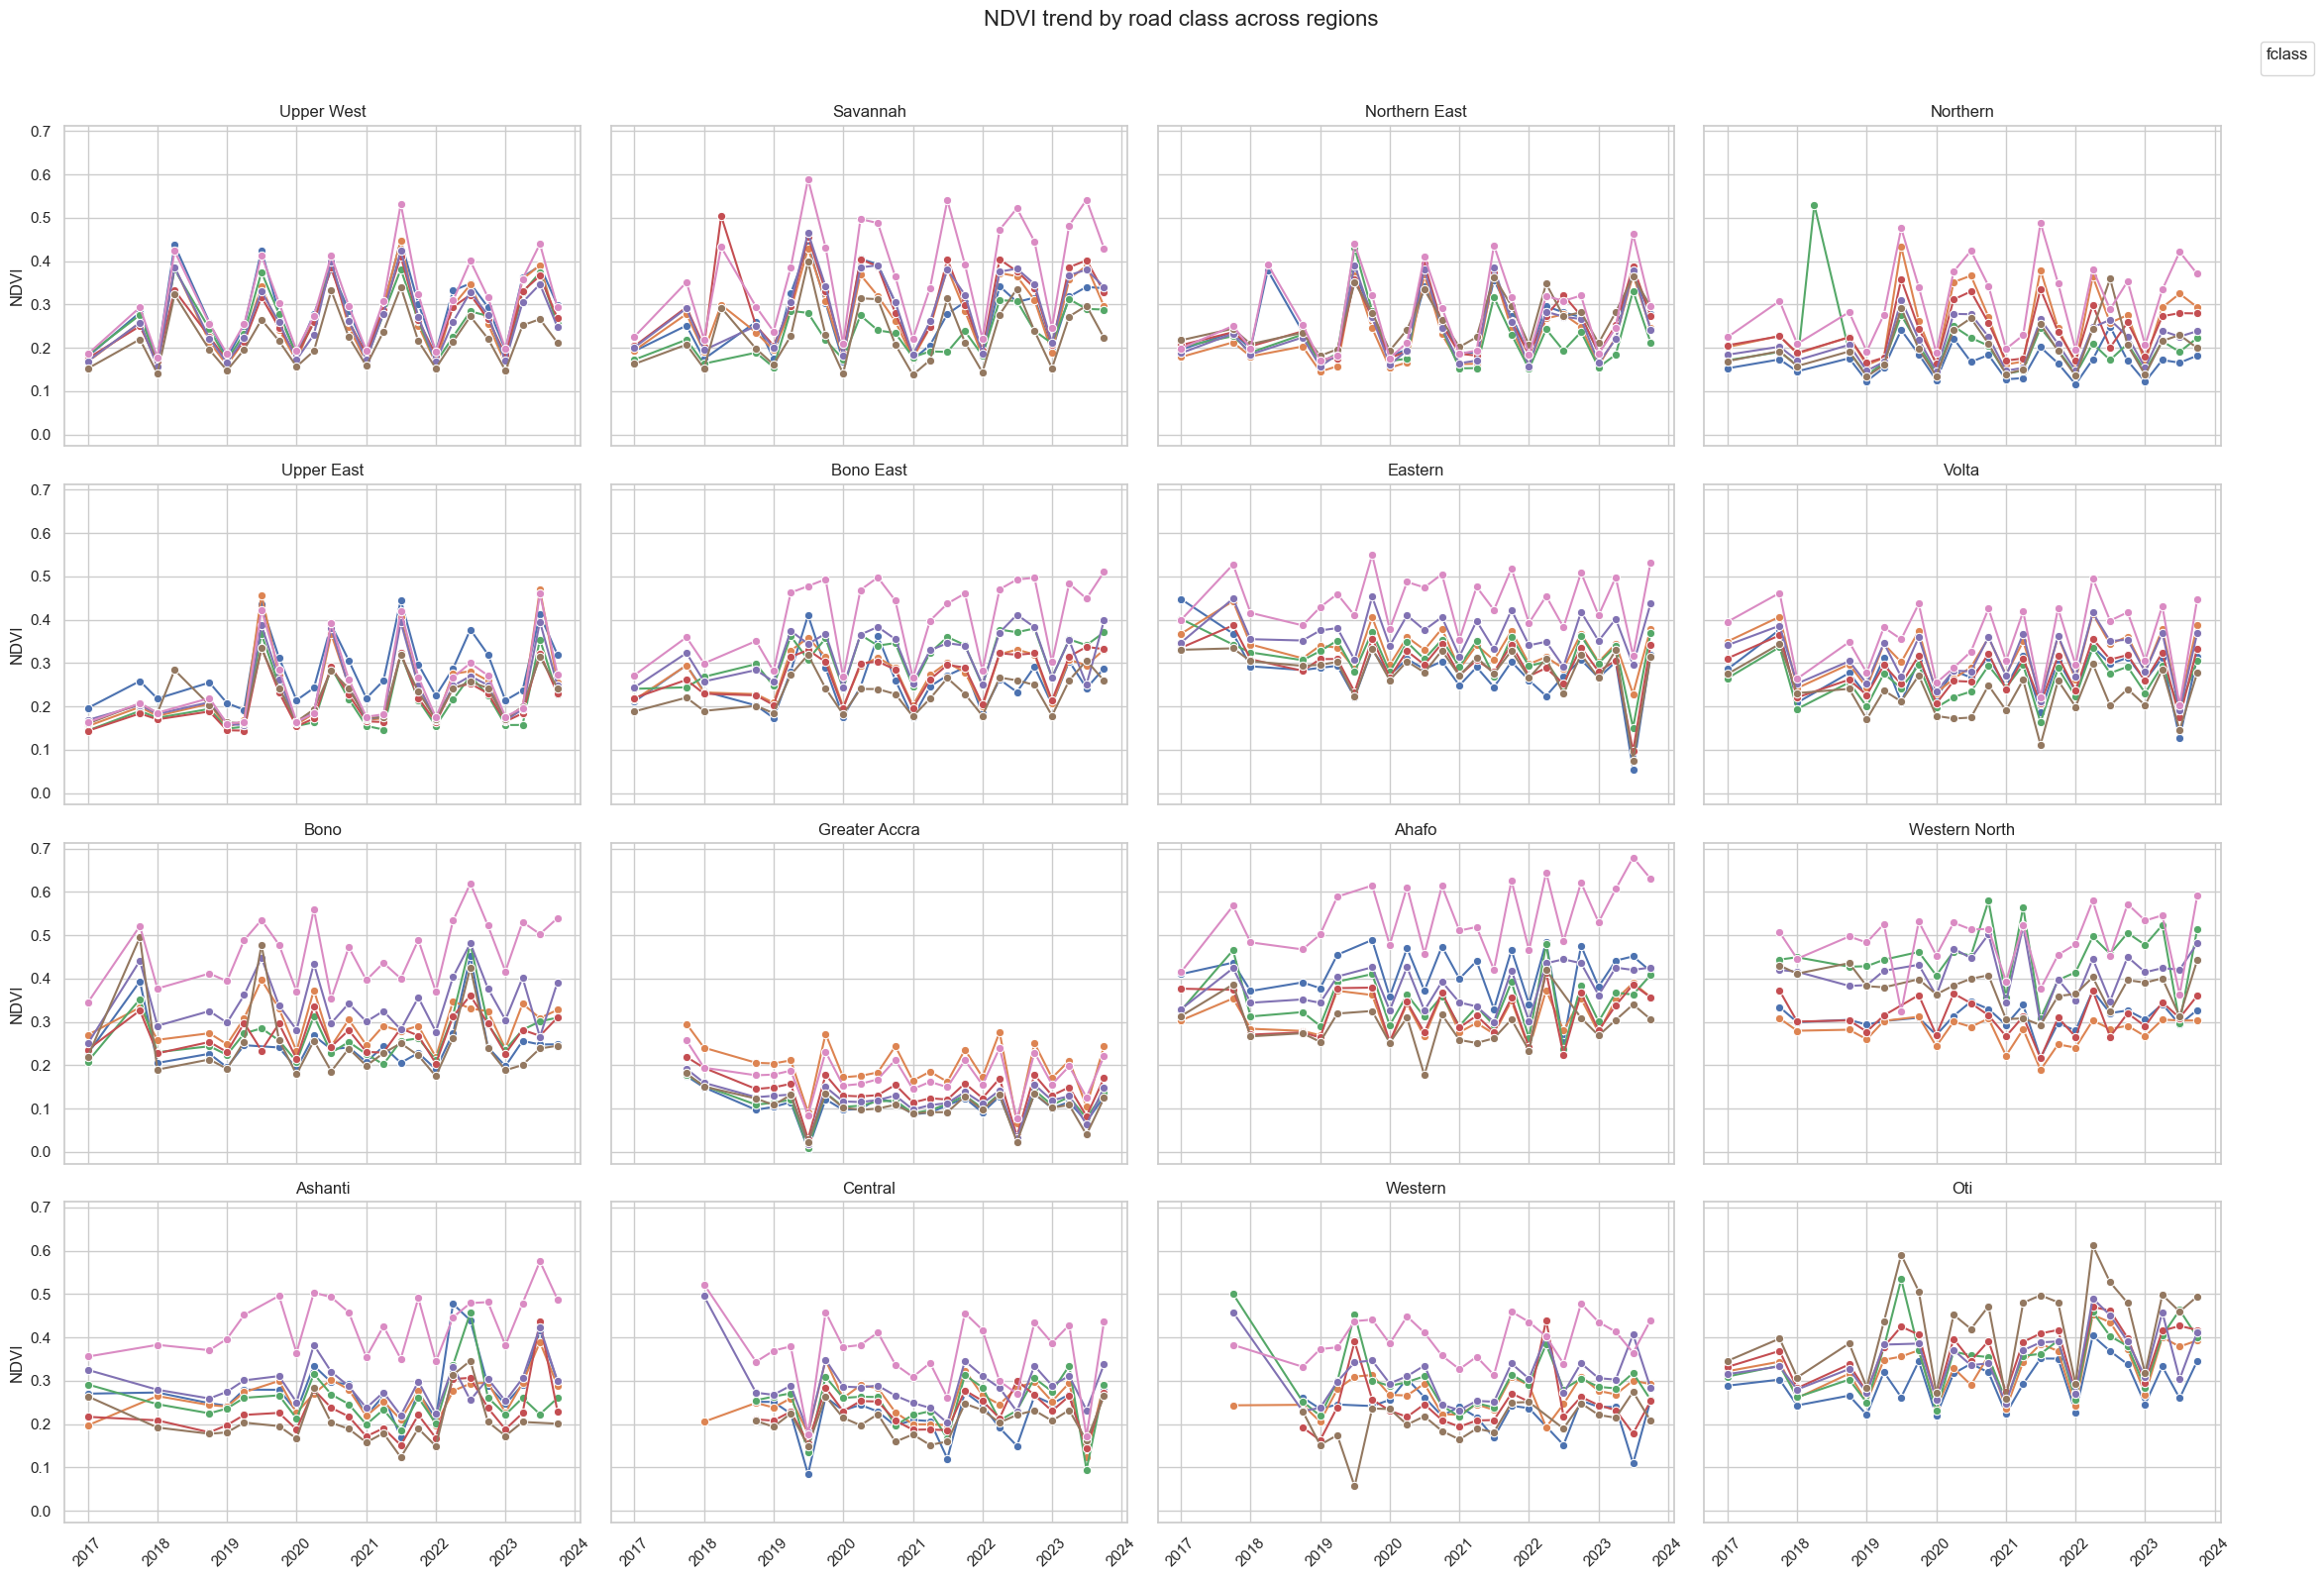

In [25]:
# Region x fclass x quarter NDVI means
reg_cls_q = (
    dfx.groupby(["region", "fclass", "t"])[["NDVI","NDMI","NDBI","NDWI","BSI"]]
    .mean()
    .reset_index()
)

focus_classes = ["primary","secondary","tertiary","residential","service","unclassified","trunk"]

# keep valid regions and select top 16
plot_df = reg_cls_q.copy()
plot_df["region"] = plot_df["region"].fillna("Unknown")
plot_df = plot_df[
    plot_df["fclass"].isin(focus_classes) &
    (~plot_df["region"].isin(["Unknown", "NaN"]))
].copy()

regions16 = (
    plot_df.groupby("region").size()
    .sort_values(ascending=False)
    .head(16)
    .index
    .tolist()
)

rows, cols = 4, 4
fig, axes = plt.subplots(rows, cols, figsize=(24, 16), sharex=True, sharey=True)
axes = axes.flatten()

for i, region in enumerate(regions16):
    ax = axes[i]
    tmp = plot_df[plot_df["region"] == region]

    sns.lineplot(
        data=tmp,
        x="t", y="NDVI",
        hue="fclass",
        marker="o",
        ax=ax,
        legend=False
    )
    ax.set_title(region)
    ax.set_xlabel("")
    ax.set_ylabel("NDVI")
    ax.tick_params(axis="x", rotation=45)

# turn off unused axes
for j in range(len(regions16), rows * cols):
    axes[j].axis("off")

# shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="fclass", loc="upper right", bbox_to_anchor=(0.98, 0.98))

fig.suptitle("NDVI trend by road class across regions", fontsize=16, y=0.995)
plt.tight_layout(rect=[0, 0, 0.95, 0.97])
plt.show()



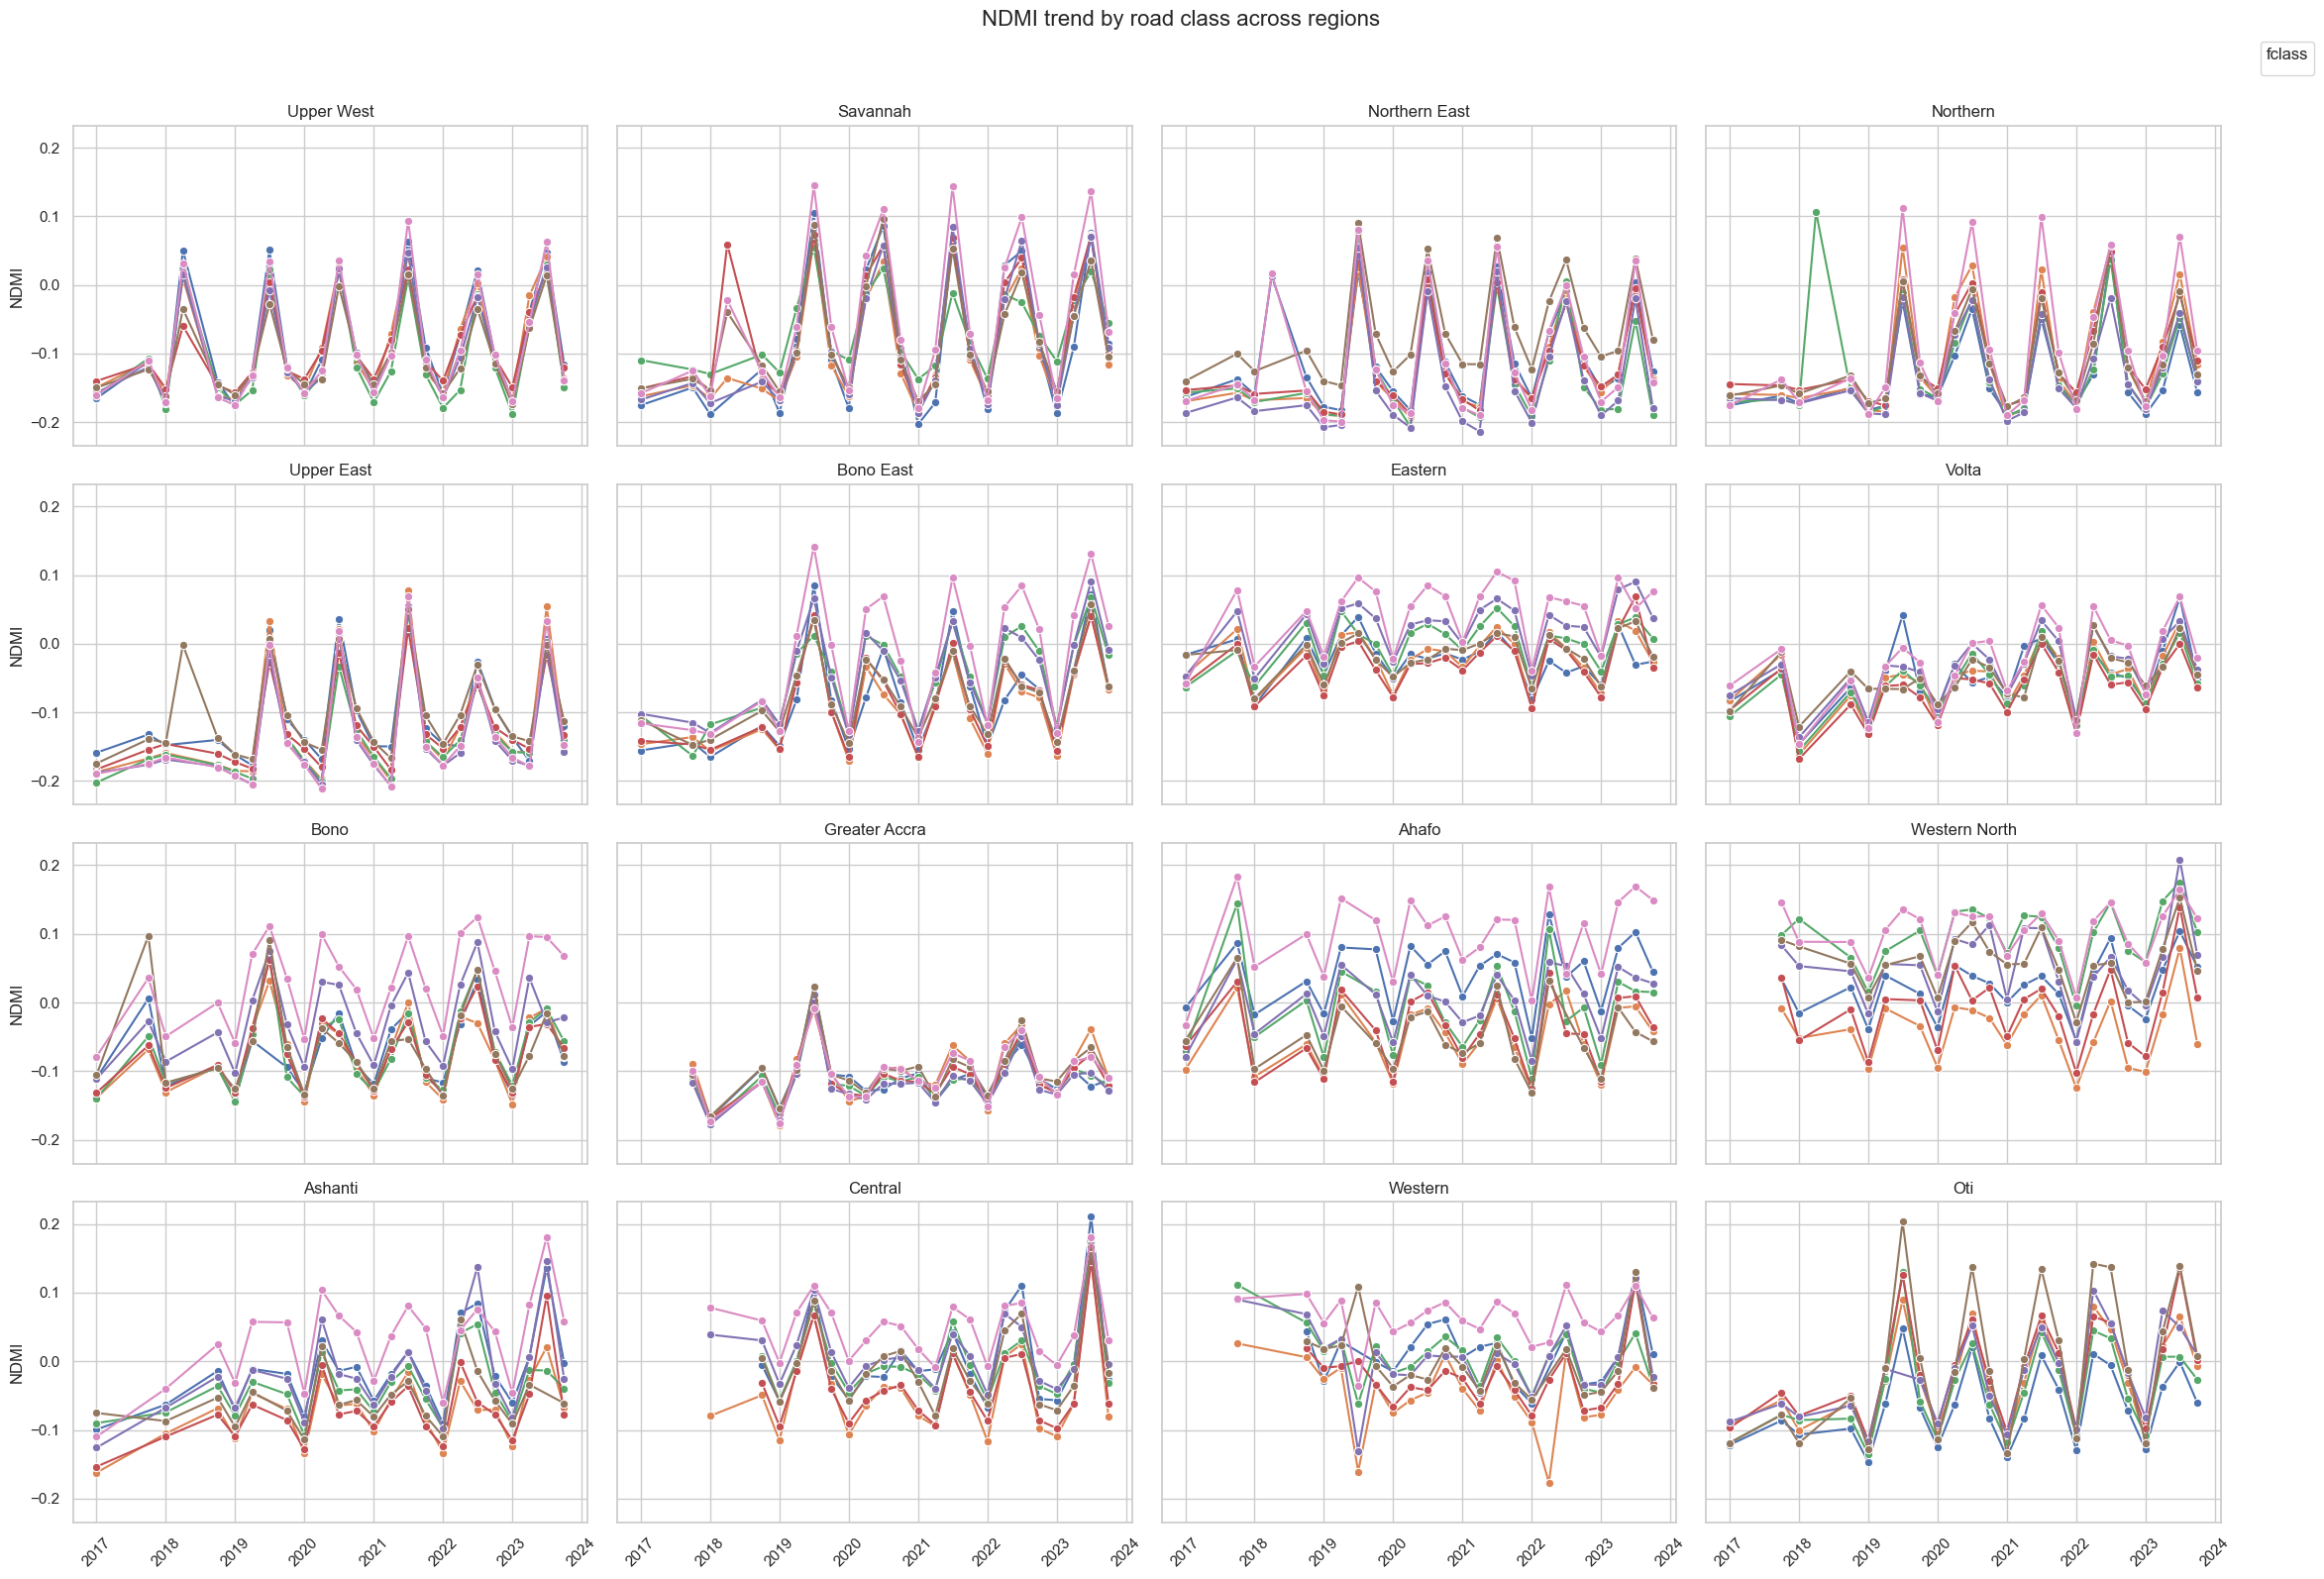

In [26]:
# Region x fclass x quarter NDMI means
reg_cls_q = (
    dfx.groupby(["region", "fclass", "t"])[["NDVI","NDMI","NDBI","NDWI","BSI"]]
    .mean()
    .reset_index()
)

focus_classes = ["primary","secondary","tertiary","residential","service","unclassified","trunk"]

# keep valid regions and select top 16
plot_df = reg_cls_q.copy()
plot_df["region"] = plot_df["region"].fillna("Unknown")
plot_df = plot_df[
    plot_df["fclass"].isin(focus_classes) &
    (~plot_df["region"].isin(["Unknown", "NaN"]))
].copy()

regions16 = (
    plot_df.groupby("region").size()
    .sort_values(ascending=False)
    .head(16)
    .index
    .tolist()
)

rows, cols = 4, 4
fig, axes = plt.subplots(rows, cols, figsize=(24, 16), sharex=True, sharey=True)
axes = axes.flatten()

for i, region in enumerate(regions16):
    ax = axes[i]
    tmp = plot_df[plot_df["region"] == region]

    sns.lineplot(
        data=tmp,
        x="t", y="NDMI",
        hue="fclass",
        marker="o",
        ax=ax,
        legend=False
    )
    ax.set_title(region)
    ax.set_xlabel("")
    ax.set_ylabel("NDMI")
    ax.tick_params(axis="x", rotation=45)

# turn off unused axes
for j in range(len(regions16), rows * cols):
    axes[j].axis("off")

# shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="fclass", loc="upper right", bbox_to_anchor=(0.98, 0.98))

fig.suptitle("NDMI trend by road class across regions", fontsize=16, y=0.995)
plt.tight_layout(rect=[0, 0, 0.95, 0.97])
plt.show()

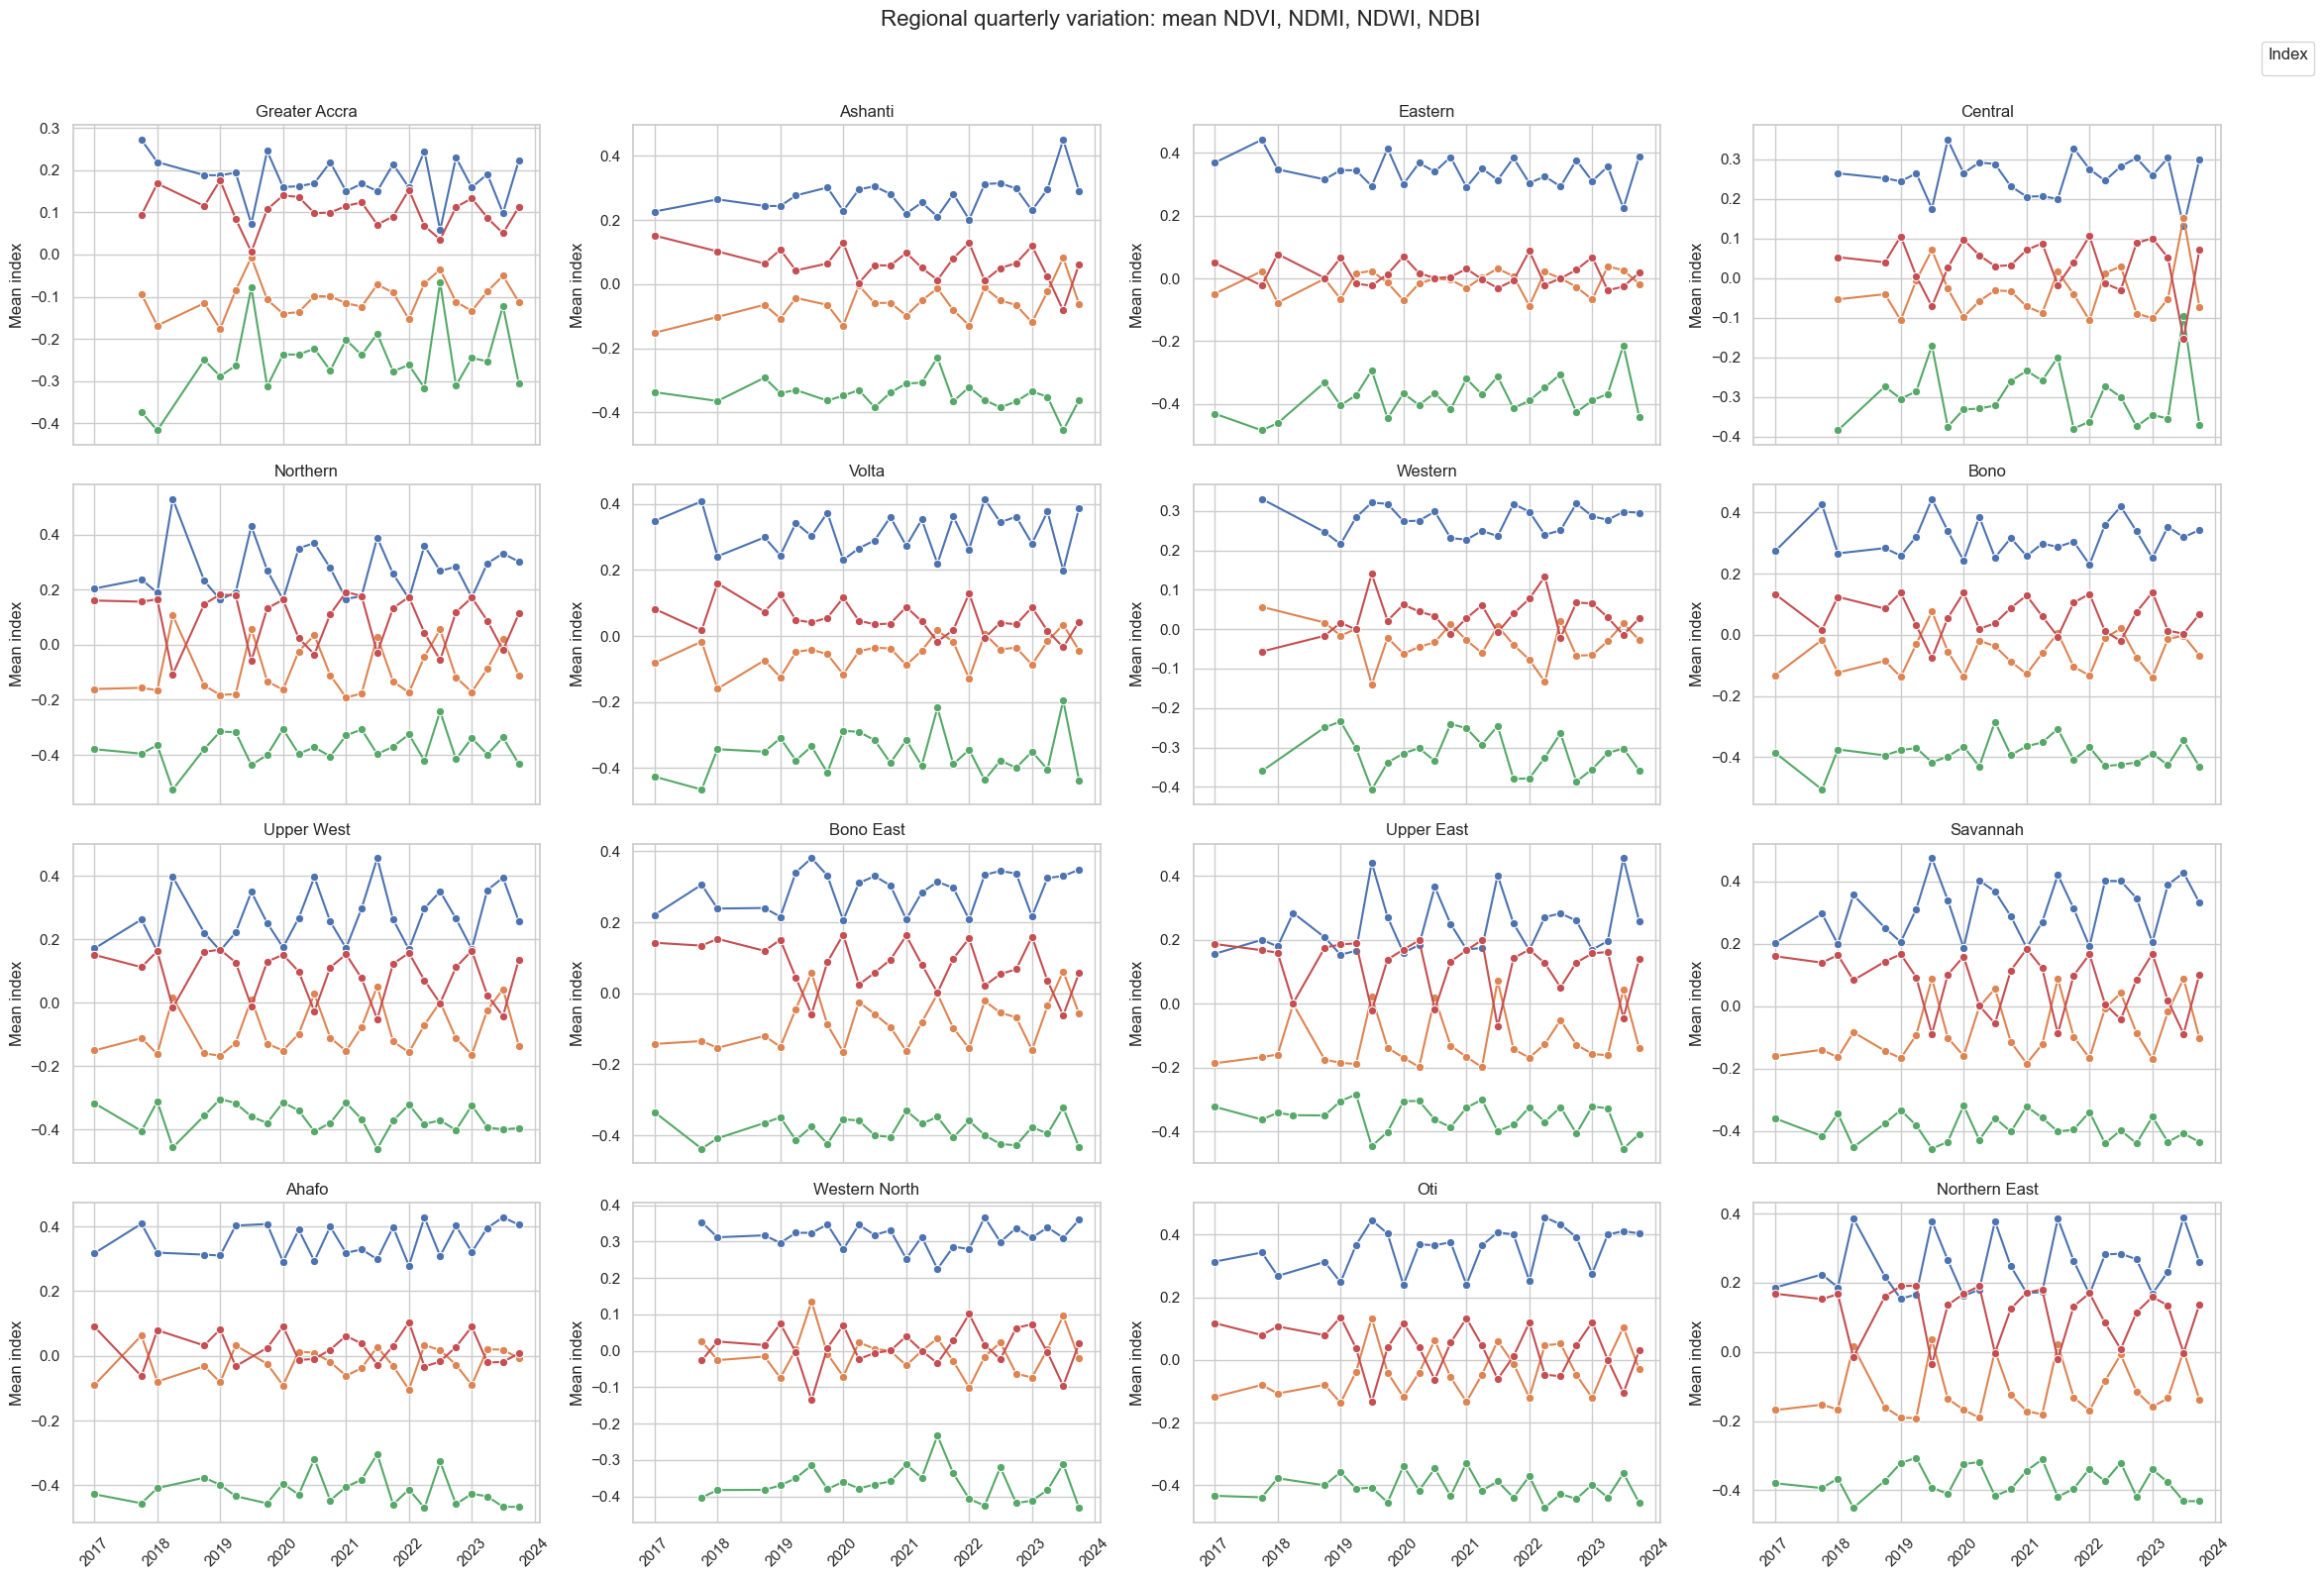

In [27]:
# Subplots by region: quarterly variation of mean NDVI, NDMI, NDWI, NDBI
# (one panel per region; 4 lines per panel)

# Build regional-quarterly means
reg_q_idx = (
    dfx.groupby(["region", "t"])[["NDVI", "NDMI", "NDWI", "NDBI"]]
    .mean()
    .reset_index()
)

# keep regions (exclude unknown for cleaner panels; remove this filter if you want them included)
reg_q_idx["region"] = reg_q_idx["region"].fillna("Unknown")
reg_q_idx = reg_q_idx[~reg_q_idx["region"].isin(["Unknown", "NaN"])].copy()

# pick 16 regions (largest by row count)
regions16 = (
    dfx.assign(region=dfx["region"].fillna("Unknown"))
       .query("region != 'Unknown' and region != 'NaN'")
       .groupby("region").size()
       .sort_values(ascending=False)
       .head(16)
       .index.tolist()
)

# reshape for seaborn
plot_df = reg_q_idx[reg_q_idx["region"].isin(regions16)].melt(
    id_vars=["region", "t"],
    value_vars=["NDVI", "NDMI", "NDWI", "NDBI"],
    var_name="index_name",
    value_name="mean_value"
)

fig, axes = plt.subplots(4, 4, figsize=(24, 16), sharex=True, sharey=False)
axes = axes.flatten()

for i, region in enumerate(regions16):
    ax = axes[i]
    tmp = plot_df[plot_df["region"] == region]

    sns.lineplot(
        data=tmp,
        x="t", y="mean_value",
        hue="index_name",
        marker="o",
        ax=ax,
        legend=False
    )
    ax.set_title(region)
    ax.set_xlabel("")
    ax.set_ylabel("Mean index")
    ax.tick_params(axis="x", rotation=45)

# turn off unused panels
for j in range(len(regions16), 16):
    axes[j].axis("off")

# shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Index", loc="upper right", bbox_to_anchor=(0.98, 0.98))

fig.suptitle("Regional quarterly variation: mean NDVI, NDMI, NDWI, NDBI", fontsize=16, y=0.995)
plt.tight_layout(rect=[0, 0, 0.95, 0.97])
plt.show()


In [28]:
# Year-over-year (YoY) change by region and road class (2020–2023)
yearly_reg_cls = (
    dfx.groupby(["region", "fclass", "year"])[["NDVI","NDMI","NDBI","NDWI","BSI"]]
    .mean()
    .reset_index()
    .sort_values(["region","fclass","year"])
)

yearly_reg_cls.head()

,region,fclass,year,NDVI,NDMI,NDBI,NDWI,BSI
0,Ahafo,primary,2017,0.417940,0.019395,-0.019395,-0.477948,0.049942
1,Ahafo,primary,2018,0.381331,0.006776,-0.006776,-0.434347,0.055225
2,Ahafo,primary,2019,0.440653,0.047076,-0.047076,-0.457844,0.006062
3,Ahafo,primary,2020,0.418658,0.046558,-0.046558,-0.435494,0.002672
4,Ahafo,primary,2021,0.408955,0.047888,-0.047888,-0.421850,-0.001118


In [29]:
# compute YoY deltas for each index
for idx in ["NDVI","NDMI","NDBI","NDWI","BSI"]:
    yearly_reg_cls[f"{idx}_yoy"] = (
        yearly_reg_cls.groupby(["region","fclass"])[idx].diff()
    )

# inspect
yearly_reg_cls.head(20)


,region,fclass,year,NDVI,NDMI,NDBI,NDWI,BSI,NDVI_yoy,NDMI_yoy,NDBI_yoy,NDWI_yoy,BSI_yoy
0,Ahafo,primary,2017,0.417940,0.019395,-0.019395,-0.477948,0.049942,NaN,NaN,NaN,NaN,NaN
1,Ahafo,primary,2018,0.381331,0.006776,-0.006776,-0.434347,0.055225,-0.036608,-0.012619,0.012619,0.043601,0.005283
2,Ahafo,primary,2019,0.440653,0.047076,-0.047076,-0.457844,0.006062,0.059322,0.040300,-0.040300,-0.023497,-0.049162
3,Ahafo,primary,2020,0.418658,0.046558,-0.046558,-0.435494,0.002672,-0.021995,-0.000518,0.000518,0.022350,-0.003391
4,Ahafo,primary,2021,0.408955,0.047888,-0.047888,-0.421850,-0.001118,-0.009703,0.001331,-0.001331,0.013643,-0.003789
5,Ahafo,primary,2022,0.420468,0.032437,-0.032437,-0.458411,0.021886,0.011513,-0.015452,0.015452,-0.036560,0.023004
6,Ahafo,primary,2023,0.422854,0.053715,-0.053715,-0.458052,0.005399,0.002386,0.021278,-0.021278,0.000358,-0.016488
7,Ahafo,residential,2017,0.338348,-0.015557,0.015557,-0.419670,0.082126,NaN,NaN,NaN,NaN,NaN
8,Ahafo,residential,2018,0.281794,-0.084388,0.084388,-0.374186,0.130890,-0.056554,-0.068832,0.068832,0.045484,0.048763
9,Ahafo,residential,2019,0.333769,-0.052479,0.052479,-0.405485,0.099894,0.051975,0.031909,-0.031909,-0.031299,-0.030995


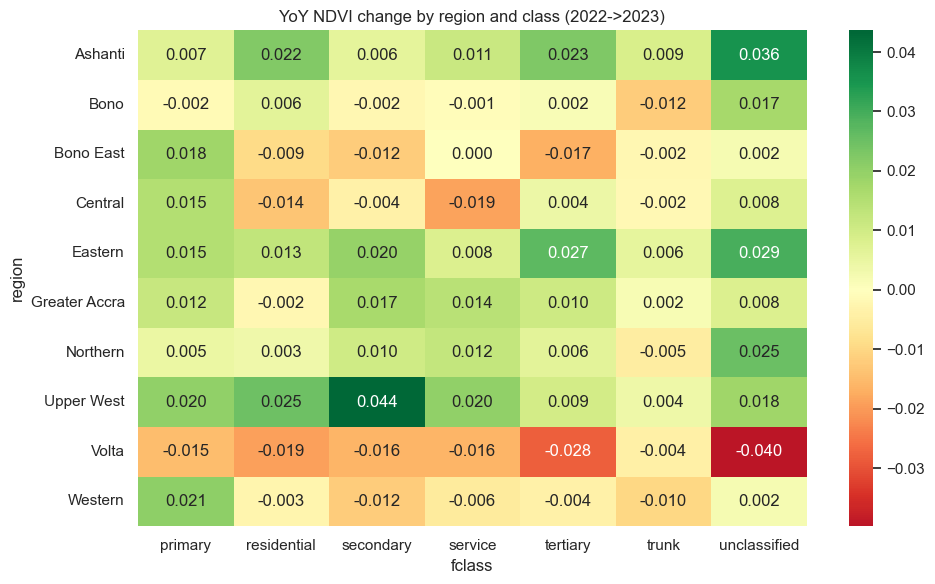

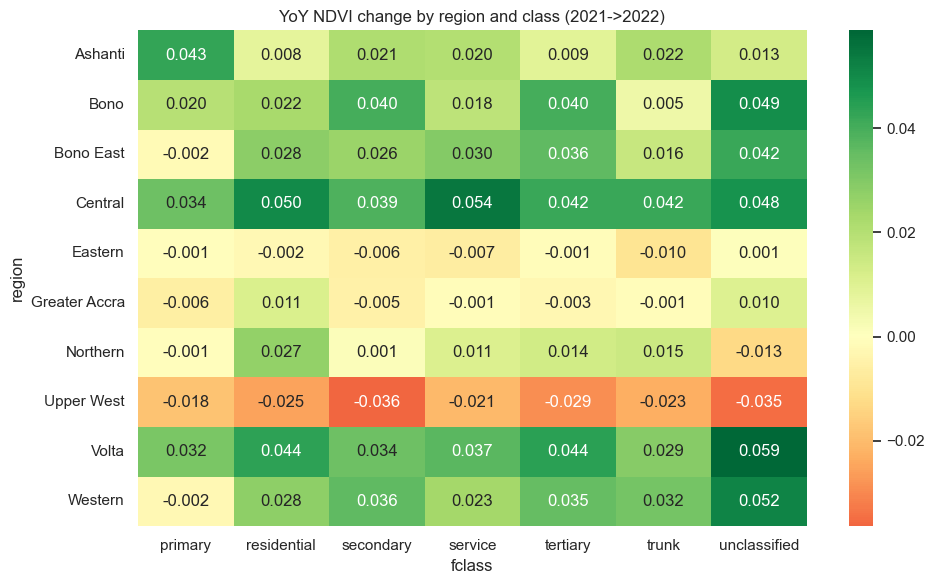

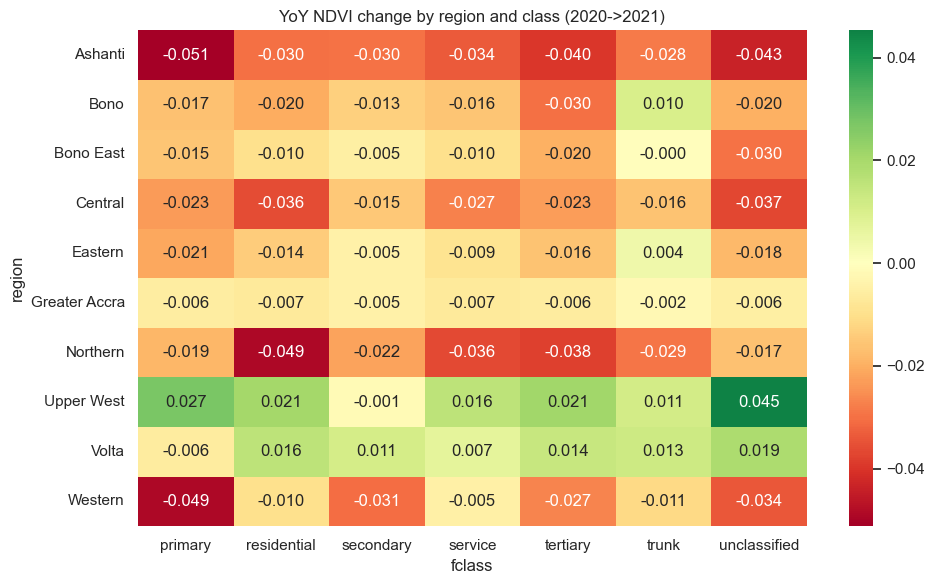

In [30]:
# YoY heatmap (example: NDVI_yoy) for selected year
# choose year = 2023 means change from 2022->2023
target_year = 2023

# keep top regions/classes for readability
top_regions = dfx["region"].value_counts().head(10).index.tolist()
focus_classes = ["primary","secondary","tertiary","residential","service","unclassified","trunk"]

hm_df = yearly_reg_cls[
    (yearly_reg_cls["year"] == target_year) &
    (yearly_reg_cls["region"].isin(top_regions)) &
    (yearly_reg_cls["fclass"].isin(focus_classes))
].copy()

pivot_hm = hm_df.pivot(index="region", columns="fclass", values="NDVI_yoy")

plt.figure(figsize=(10,6))
sns.heatmap(pivot_hm, annot=True, cmap="RdYlGn", center=0, fmt=".3f")
plt.title(f"YoY NDVI change by region and class ({target_year-1}->{target_year})")
plt.tight_layout()
plt.show()


target_year = 2022

# keep top regions/classes for readability
top_regions = dfx["region"].value_counts().head(10).index.tolist()
focus_classes = ["primary","secondary","tertiary","residential","service","unclassified","trunk"]

hm_df = yearly_reg_cls[
    (yearly_reg_cls["year"] == target_year) &
    (yearly_reg_cls["region"].isin(top_regions)) &
    (yearly_reg_cls["fclass"].isin(focus_classes))
].copy()

pivot_hm = hm_df.pivot(index="region", columns="fclass", values="NDVI_yoy")

plt.figure(figsize=(10,6))
sns.heatmap(pivot_hm, annot=True, cmap="RdYlGn", center=0, fmt=".3f")
plt.title(f"YoY NDVI change by region and class ({target_year-1}->{target_year})")
plt.tight_layout()
plt.show()


target_year = 2021

# keep top regions/classes for readability
top_regions = dfx["region"].value_counts().head(10).index.tolist()
focus_classes = ["primary","secondary","tertiary","residential","service","unclassified","trunk"]

hm_df = yearly_reg_cls[
    (yearly_reg_cls["year"] == target_year) &
    (yearly_reg_cls["region"].isin(top_regions)) &
    (yearly_reg_cls["fclass"].isin(focus_classes))
].copy()

pivot_hm = hm_df.pivot(index="region", columns="fclass", values="NDVI_yoy")

plt.figure(figsize=(10,6))
sns.heatmap(pivot_hm, annot=True, cmap="RdYlGn", center=0, fmt=".3f")
plt.title(f"YoY NDVI change by region and class ({target_year-1}->{target_year})")
plt.tight_layout()
plt.show()


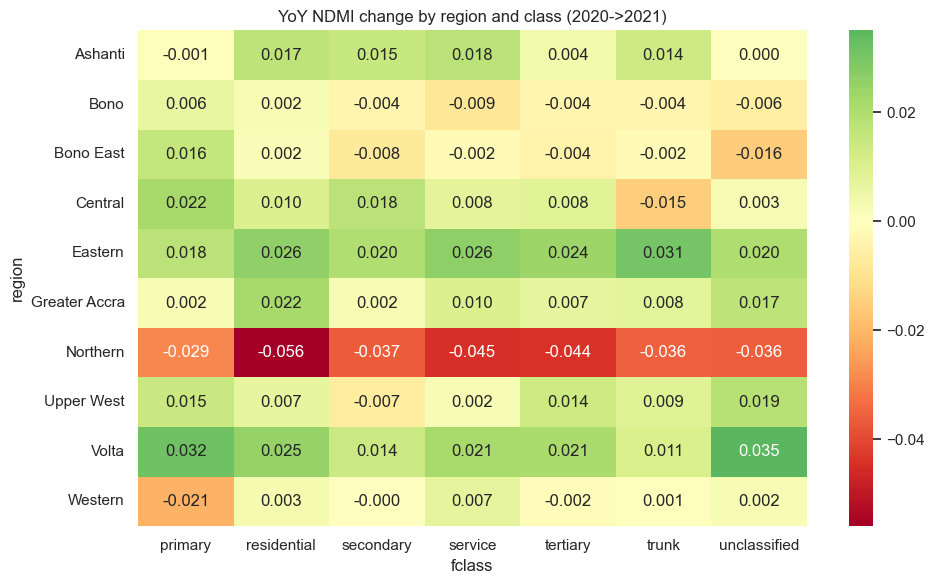

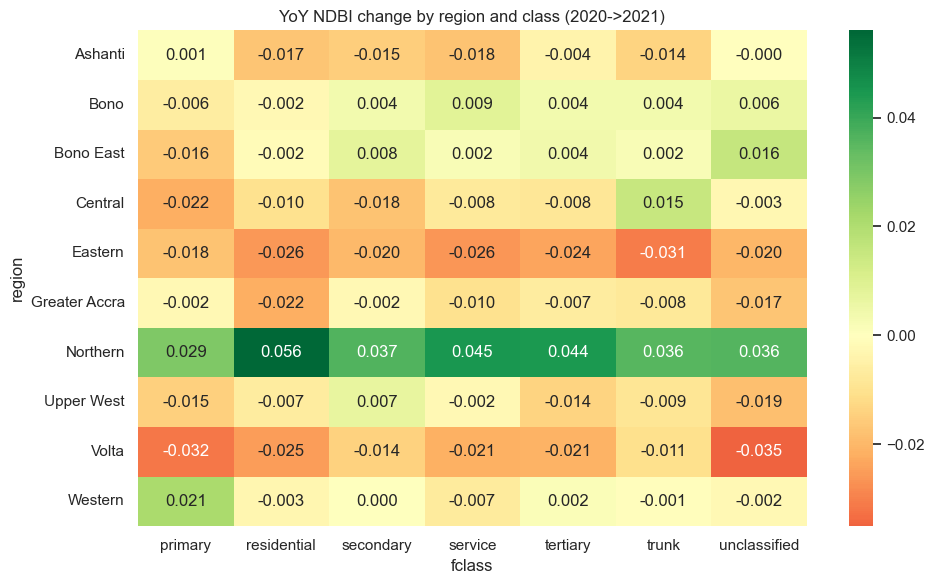

: 

In [ ]:
# repeat for wetness/build-up (NDMI_yoy and NDBI_yoy)
for metric in ["NDMI_yoy", "NDBI_yoy"]:
    pivot_hm = hm_df.pivot(index="region", columns="fclass", values=metric)
    plt.figure(figsize=(10,6))
    sns.heatmap(pivot_hm, annot=True, cmap="RdYlGn", center=0, fmt=".3f")
    plt.title(f"YoY {metric.replace('_yoy','')} change by region and class ({target_year-1}->{target_year})")
    plt.tight_layout()
    plt.show()


# Additional Data sources

In [ ]:
# Geofabrik file 

from pyrosm import OSM

pbf_path = str(DATA_DIR / "ghana-260415.osm.pbf")
osm = OSM(pbf_path)

# get drivable road network with tags
roads = osm.get_network(network_type="driving")
roads.head()
roads.columns

In [ ]:
# how populated are key quality-related OSM tags?
for c in ["surface", "smoothness", "tracktype", "maxspeed", "highway"]:
    print(c, "non-null:", roads[c].notna().sum(), "of", len(roads))

# top values
print("\nSurface top values:")
print(roads["surface"].value_counts(dropna=False).head(20))

print("\nSmoothness top values:")
print(roads["smoothness"].value_counts(dropna=False).head(20))

print("\nTracktype top values:")
print(roads["tracktype"].value_counts(dropna=False).head(20))


In [ ]:
# keep labelled subset for potential future use

roads = roads.copy()
roads["surface_clean"] = roads["surface"].astype("string").str.lower().str.strip()

paved_vals = {
    "asphalt", "paved", "concrete", "concrete:plates",
    "paving_stones", "sett"
}
unpaved_vals = {
    "unpaved", "ground", "dirt", "earth", "gravel",
    "fine_gravel", "sand", "mud", "grass", "compacted"
}

# initialize as missing (string dtype)
roads["paved_label"] = pd.Series(pd.NA, index=roads.index, dtype="string")

roads.loc[roads["surface_clean"].isin(paved_vals), "paved_label"] = "paved"
roads.loc[roads["surface_clean"].isin(unpaved_vals), "paved_label"] = "unpaved"

print(roads["paved_label"].value_counts(dropna=False))



In [ ]:
# 2) keep only reliable labeled subset
roads_lbl = roads.dropna(subset=["paved_label"]).copy()
print("Labeled roads:", len(roads_lbl))
roads_lbl[["id", "highway", "surface", "paved_label"]].head()


In [ ]:
# 3) quick class composition of labeled subset
pd.crosstab(roads_lbl["highway"], roads_lbl["paved_label"], normalize="index").round(3)


In [ ]:
# Keep only target classes + build clean paved/unpaved labels table
focus_classes = ["residential", "service", "trunk", "primary", "secondary", "tertiary", "unclassified"]

# roads = pyrosm roads GeoDataFrame with columns: id, highway, paved_label
lbl = roads.copy()
lbl = lbl[lbl["highway"].isin(focus_classes)].copy()
lbl = lbl[lbl["paved_label"].isin(["paved", "unpaved"])].copy()

# key alignment for merge
lbl["osm_id"] = lbl["id"].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()

print("Labeled rows in focus classes:", len(lbl))
lbl[["osm_id", "highway", "paved_label"]].head()


In [ ]:
# Merge labels into Sentinel table
# df_all should have: osm_id, fclass, NDVI, NDMI, NDBI, NDWI, BSI, year, quarter
s2 = df_reg.copy()
s2["osm_id"] = s2["osm_id"].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()
s2 = s2[s2["fclass"].isin(focus_classes)].copy()

# Deduplicate label table to one row per osm_id
lbl_u = lbl[["osm_id", "paved_label", "highway"]].drop_duplicates("osm_id")

cmp_df = s2.merge(lbl_u, on="osm_id", how="inner")
# optional consistency check (fclass vs highway name)
cmp_df["class_match"] = (cmp_df["fclass"] == cmp_df["highway"])

print("Merged rows:", len(cmp_df))
print("Unique roads merged:", cmp_df["osm_id"].nunique())
cmp_df.head()


In [ ]:
# Number of identified paved vs unpaved by class
count_table = (
    cmp_df.groupby(["fclass", "paved_label"])["osm_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(focus_classes)
)

count_table["total_labeled_roads"] = count_table.sum(axis=1)
count_table["paved_pct"] = (count_table.get("paved", 0) / count_table["total_labeled_roads"] * 100).round(2)
count_table["unpaved_pct"] = (count_table.get("unpaved", 0) / count_table["total_labeled_roads"] * 100).round(2)

count_table


In [ ]:
# Bar chart: paved vs unpaved counts per class
import matplotlib.pyplot as plt

plot_counts = count_table[["paved", "unpaved"]].fillna(0)
ax = plot_counts.plot(kind="bar", figsize=(10,5))
ax.set_title("Labeled roads by class: paved vs unpaved")
ax.set_xlabel("fclass")
ax.set_ylabel("Unique road count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
# Numeric comparison (mean/median) of indices by class and paved_label
idx_cols = ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]

summary = (
    cmp_df.groupby(["fclass", "paved_label"])[idx_cols]
    .agg(["mean", "median", "std"])
)

summary


In [ ]:
#  Boxplots: each index, paved vs unpaved, split by class
import seaborn as sns

for c in idx_cols:
    plt.figure(figsize=(11,5))
    sns.boxplot(
        data=cmp_df,
        x="fclass",
        y=c,
        hue="paved_label",
        showfliers=False
    )
    plt.title(f"{c}: paved vs unpaved by road class")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


In [ ]:
# Regional distribution of labeled paved vs unpaved roads

cmp_df["region"] = cmp_df["region"].fillna("Unknown")

# unique roads by region x paved_label
region_pu = (
    cmp_df.groupby(["region", "paved_label"])["osm_id"]
    .nunique()
    .unstack(fill_value=0)
    .sort_values(by=["paved", "unpaved"], ascending=False)
)

region_pu["total_labeled_roads"] = region_pu.sum(axis=1)
region_pu["paved_pct"] = (region_pu.get("paved", 0) / region_pu["total_labeled_roads"] * 100).round(2)
region_pu["unpaved_pct"] = (region_pu.get("unpaved", 0) / region_pu["total_labeled_roads"] * 100).round(2)

region_pu

In [ ]:
# bar chart: counts by region
ax = region_pu[["paved", "unpaved"]].plot(kind="bar", figsize=(14,6))
ax.set_title("Paved vs unpaved roads by region (labeled subset)")
ax.set_xlabel("Region")
ax.set_ylabel("Unique road count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# stacked percentage chart by region
region_pct = region_pu[["paved_pct", "unpaved_pct"]].copy()
ax = region_pct.plot(kind="bar", stacked=True, figsize=(14,6))
ax.set_title("Paved vs unpaved share by region (%)")
ax.set_xlabel("Region")
ax.set_ylabel("Percent")
plt.xticks(rotation=45, ha="right")
plt.legend(["Paved %", "Unpaved %"], bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from scipy.stats import pointbiserialr, spearmanr

# keep only binary labels
tmp = cmp_df[cmp_df["paved_label"].isin(["paved", "unpaved"])].copy()
tmp["paved_bin"] = (tmp["paved_label"] == "paved").astype(int)

idx_cols = ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]

rows = []
for c in idx_cols:
    d = tmp[["paved_bin", c]].dropna()
    if len(d) > 10:
        r_pb, p_pb = pointbiserialr(d["paved_bin"], d[c])   # linear association
        r_sp, p_sp = spearmanr(d["paved_bin"], d[c])        # rank/monotonic
        rows.append({
            "index": c,
            "point_biserial_r": r_pb,
            "point_biserial_p": p_pb,
            "spearman_rho": r_sp,
            "spearman_p": p_sp,
            "n": len(d)
        })

corr_tbl = pd.DataFrame(rows).sort_values("point_biserial_r", ascending=False)
corr_tbl
